In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# load
BASE_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht")

PLOTS_DIR = BASE_PATH / "feature_robustness_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# features to plot 
selected_features = {
    "F0 Mean": "F0semitoneFrom27.5Hz_sma3nz_amean",
    "F0 20th%": "F0semitoneFrom27.5Hz_sma3nz_percentile20.0",
    "F0 50th%": "F0semitoneFrom27.5Hz_sma3nz_percentile50.0",
    "F0 80th%": "F0semitoneFrom27.5Hz_sma3nz_percentile80.0",
    "F0 StdDev": "F0semitoneFrom27.5Hz_sma3nz_stddevNorm",
    "F1 Mean": "F1frequency_sma3nz_amean",
    "F1 StdDev": "F1frequency_sma3nz_stddevNorm",
    "F2 Mean": "F2frequency_sma3nz_amean",
    "F2 StdDev": "F2frequency_sma3nz_stddevNorm",
    "F3 Mean": "F3frequency_sma3nz_amean",
    "F3 StdDev": "F3frequency_sma3nz_stddevNorm",
    "HNR Mean": "HNRdBACF_sma3nz_amean",
    "HNR StdDev": "HNRdBACF_sma3nz_stddevNorm",
    "Jitter Mean": "jitterLocal_sma3nz_amean",
    "Amplitude Mean": "loudness_sma3_amean",
    "Amplitude 20th%": "loudness_sma3_percentile20.0",
    "Amplitude 50th%": "loudness_sma3_percentile50.0",
    "Amplitude 80th%": "loudness_sma3_percentile80.0",
    "Amplitude StdDev": "loudness_sma3_stddevNorm",
    "MFCC1 Mean": "mfcc1_sma3_amean",
    "MFCC1 StdDev": "mfcc1_sma3_stddevNorm",
    "MFCC2 Mean": "mfcc2_sma3_amean",
    "MFCC2 StdDev": "mfcc2_sma3_stddevNorm",
    "MFCC3 Mean": "mfcc3_sma3_amean",
    "MFCC3 StdDev": "mfcc3_sma3_stddevNorm",
    "MFCC4 Mean": "mfcc4_sma3_amean",
    "MFCC4 StdDev": "mfcc4_sma3_stddevNorm",
    "Shimmer Mean": "shimmerLocaldB_sma3nz_amean",
}

# files of the different perturbations
perturbation_groups = {
    "Intensity": {
        "original": BASE_PATH / "opensmile_wiener_features_pain.csv",
        "-6": BASE_PATH / "opensmile_intensity_-6dB_features_pain.csv",
        "-3": BASE_PATH / "opensmile_intensity_-3dB_features_pain.csv",
        "+3": BASE_PATH / "opensmile_intensity_3dB_features_pain.csv",
        "+6": BASE_PATH / "opensmile_intensity_6dB_features_pain.csv",
    },
    "Gaussian noise": {
        "original": BASE_PATH / "opensmile_wiener_features_pain.csv",
        "0.5": BASE_PATH / "opensmile_low_gaussian_features_pain.csv",
        "2": BASE_PATH / "opensmile_medium_gaussian_features_pain.csv",
        "5": BASE_PATH / "opensmile_high_gaussian_features_pain.csv",
        "10": BASE_PATH / "opensmile_very_high_gaussian_features_pain.csv",
    },
    "Pink noise": {
        "original": BASE_PATH / "opensmile_wiener_features_pain.csv",
        "0.5": BASE_PATH / "opensmile_low_pink_features_pain.csv",
        "2": BASE_PATH / "opensmile_medium_pink_features_pain.csv",
        "5": BASE_PATH / "opensmile_high_pink_features_pain.csv",
        "10": BASE_PATH / "opensmile_very_high_pink_features_pain.csv",
    },
    "Low-pass filter": {
        "original": BASE_PATH / "opensmile_wiener_features_pain.csv",
        "6000": BASE_PATH / "opensmile_low_lowpass_features_pain.csv",
        "5000": BASE_PATH / "opensmile_medium_lowpass_features_pain.csv",
        "4000": BASE_PATH / "opensmile_high_lowpass_features_pain.csv",
        "3000": BASE_PATH / "opensmile_very_high_lowpass_features_pain.csv",
    },
}

# Helper functions
def load_and_sort_csv(file_path):
    """Load CSV and sort consistently on participant_id and filename."""
    df = pd.read_csv(file_path)
    df = df.sort_values(by=["participant_id", "filename"]).reset_index(drop=True)
    return df

def check_alignment(reference_df, comparison_df, label):
    """Check whether participant_id and filename are aligned."""
    ref_ids = reference_df[["participant_id", "filename"]]
    cmp_ids = comparison_df[["participant_id", "filename"]]

    if not ref_ids.equals(cmp_ids):
        raise ValueError(f"Mismatch in rows for {label}")

def safe_filename(text):
    """Make a string safe to use as filename."""
    return (
        text.replace("%", "percent")
            .replace(" ", "_")
            .replace("/", "_")
            .replace("-", "_")
            .replace("(", "")
            .replace(")", "")
    )

# Load data
all_data = {}

for group_name, files in perturbation_groups.items():
    all_data[group_name] = {}
    for label, file_path in files.items():
        all_data[group_name][label] = load_and_sort_csv(file_path)

# Check alignment of all dataframes
for group_name, dfs in all_data.items():
    original_df = dfs["original"]

    for label, df in dfs.items():
        if label == "original":
            continue
        check_alignment(original_df, df, f"{group_name} - {label}")

# Check whether features exist in original dataframe
reference_original = all_data["Intensity"]["original"]

missing_features = [
    feature_col
    for feature_col in selected_features.values()
    if feature_col not in reference_original.columns
]

if missing_features:
    raise ValueError(f"These features are missing from the CSV: {missing_features}")



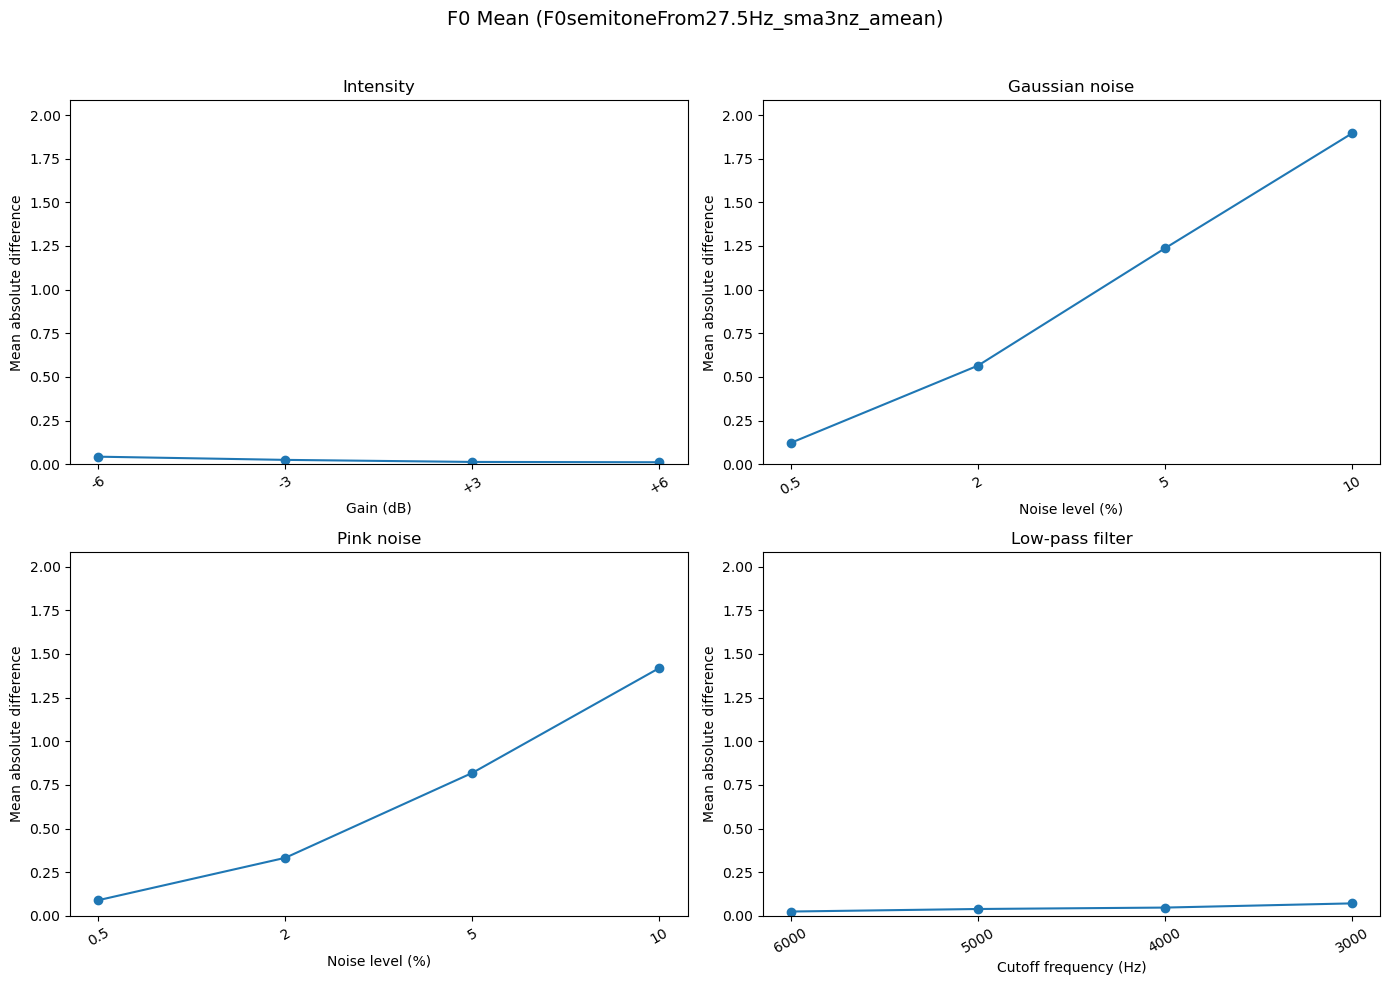

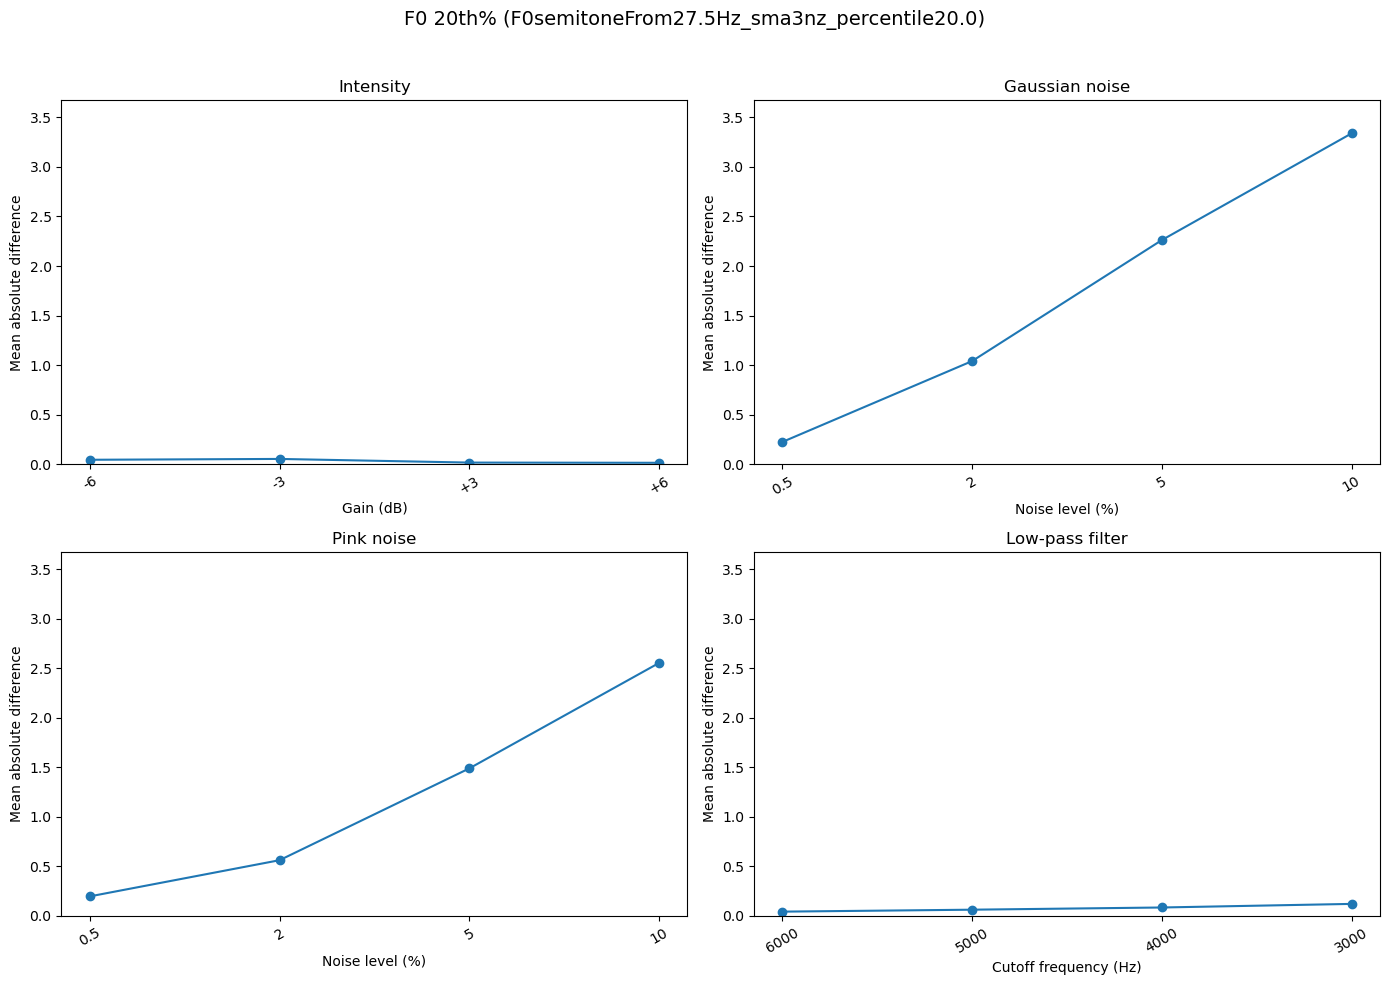

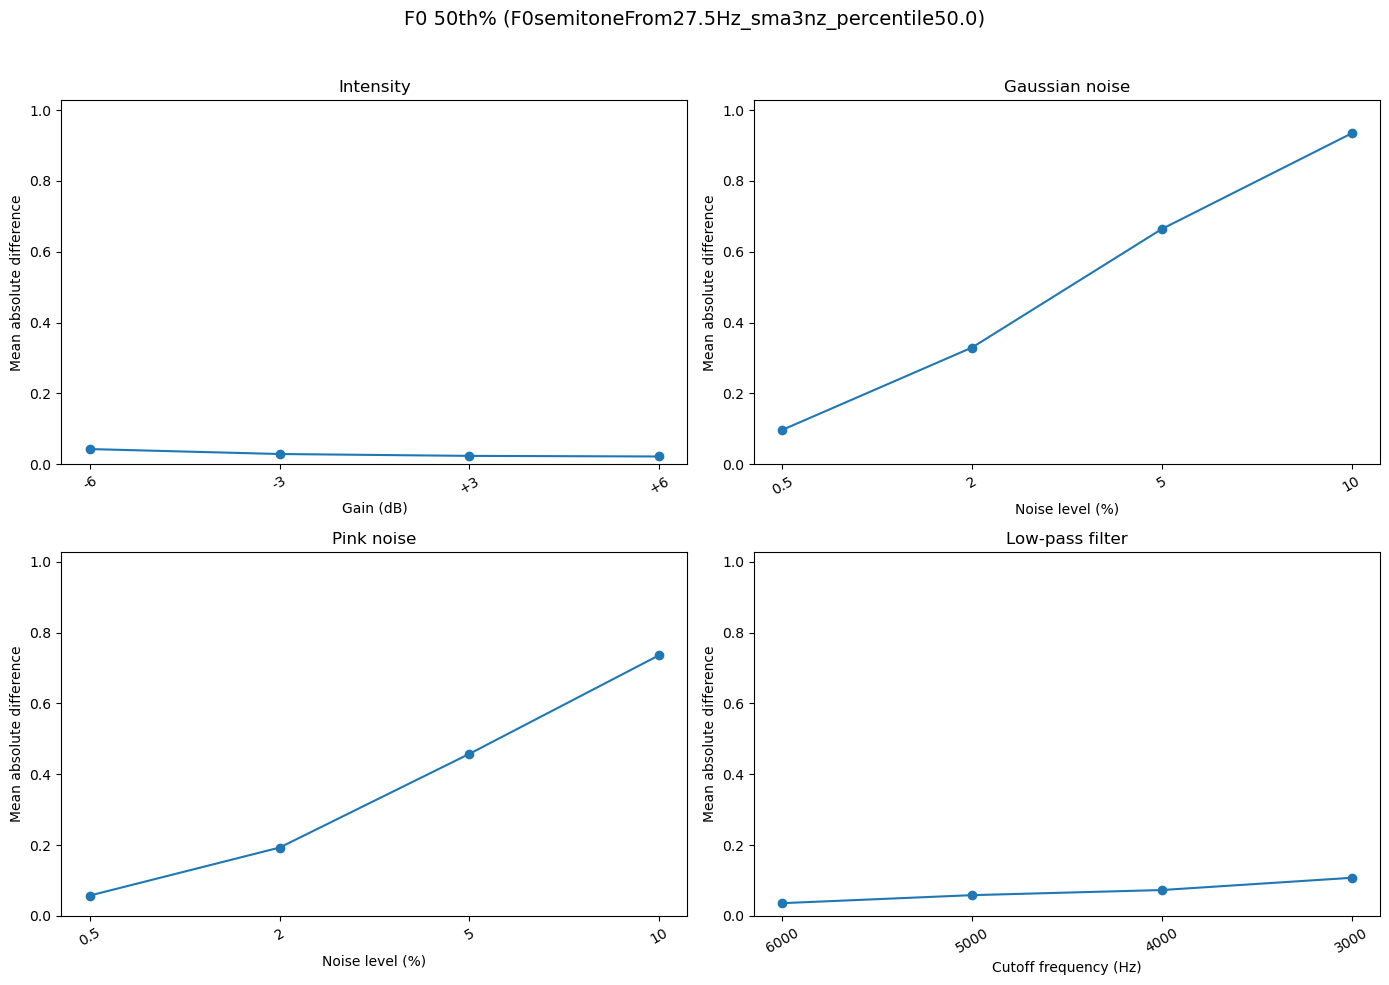

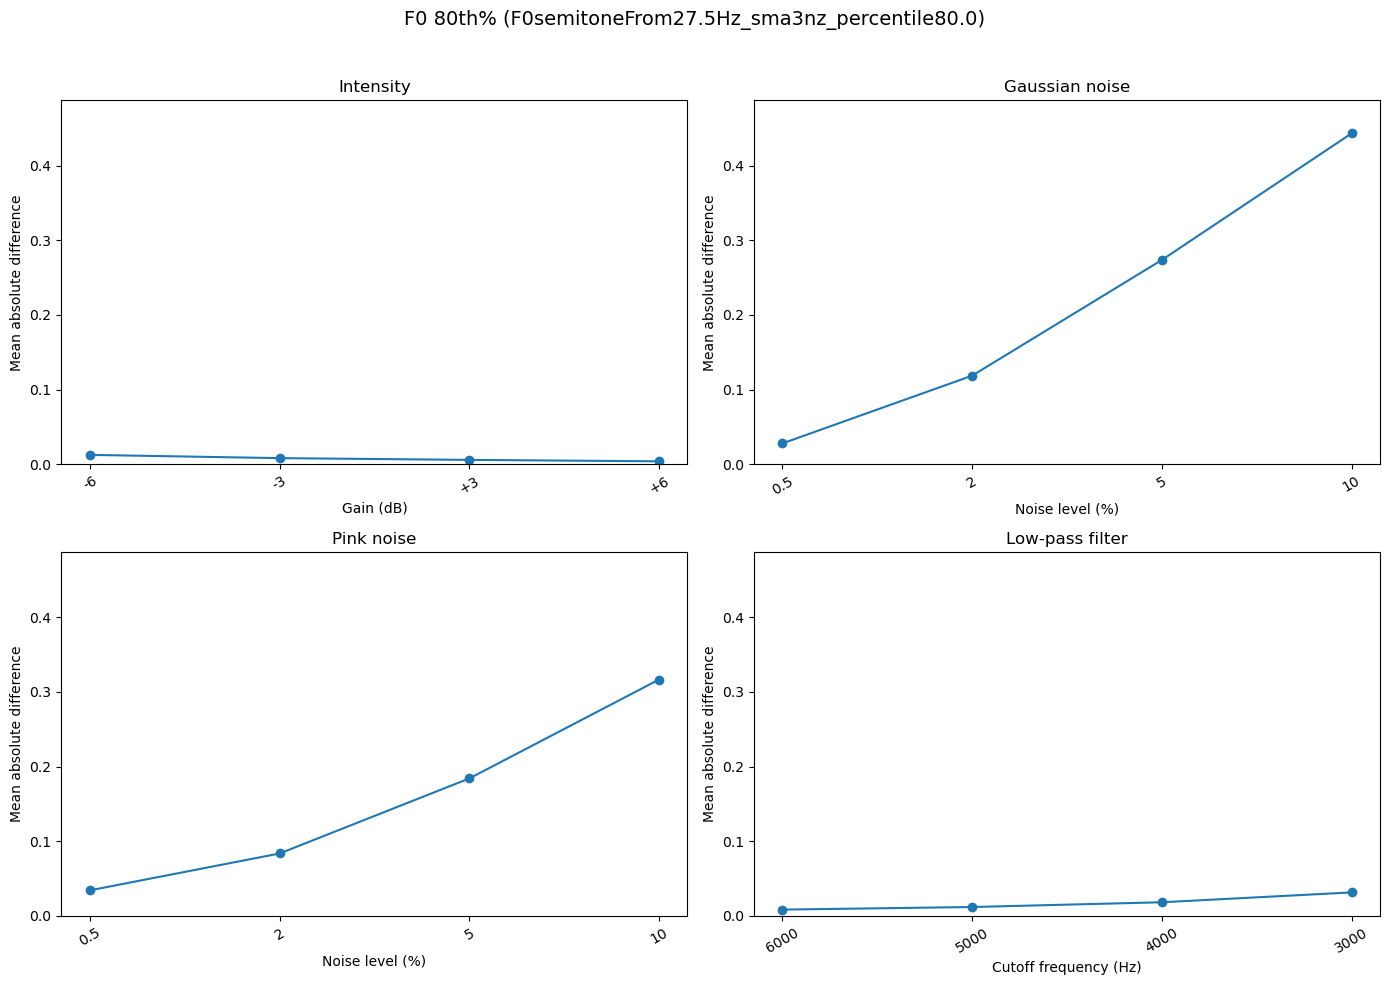

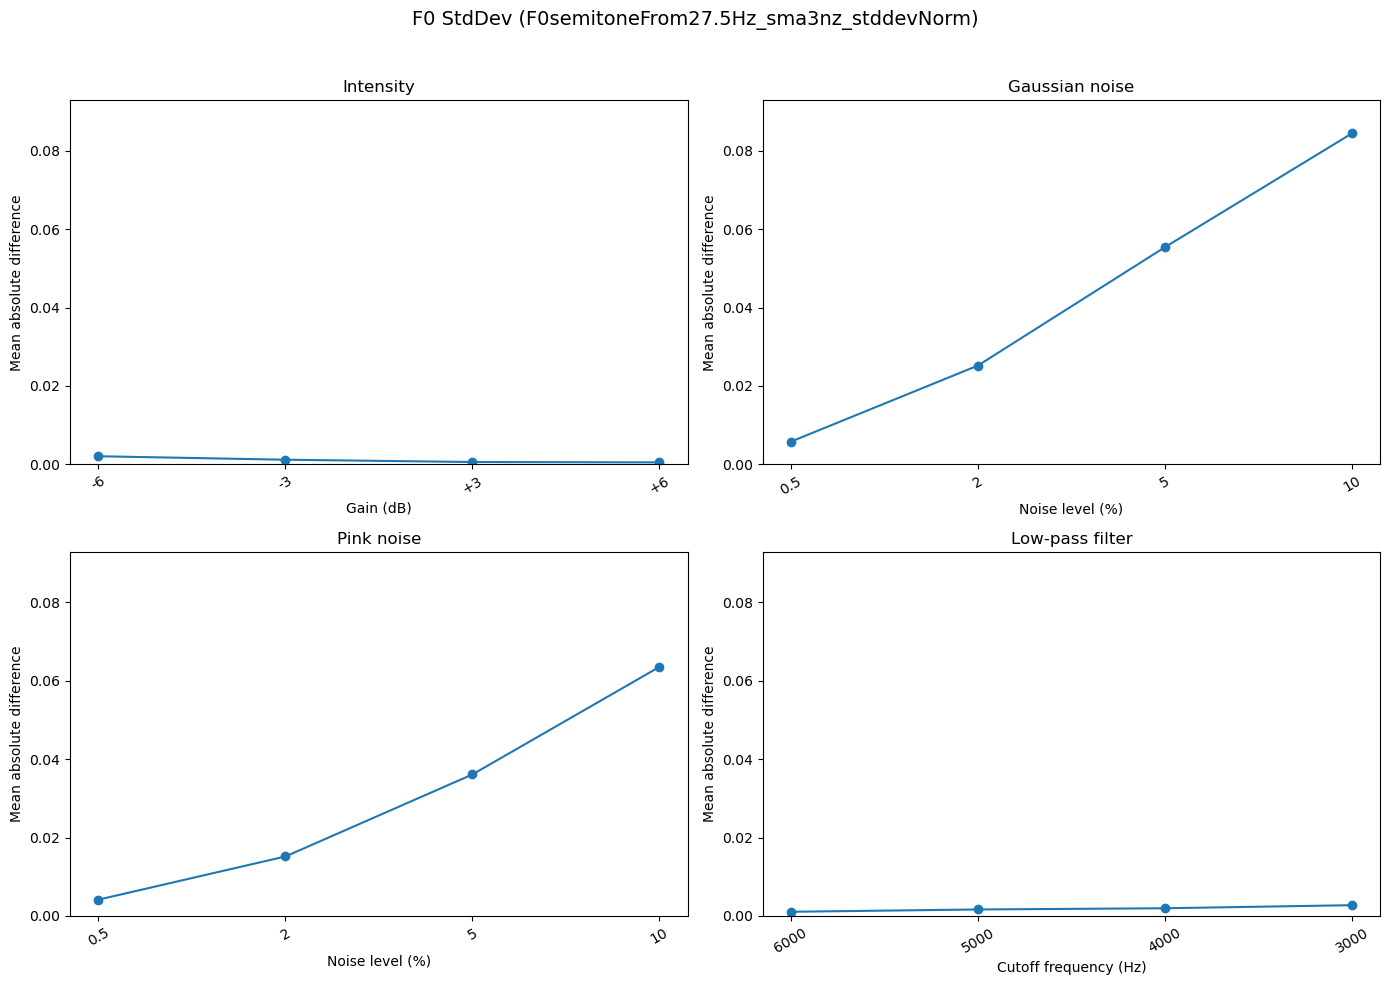

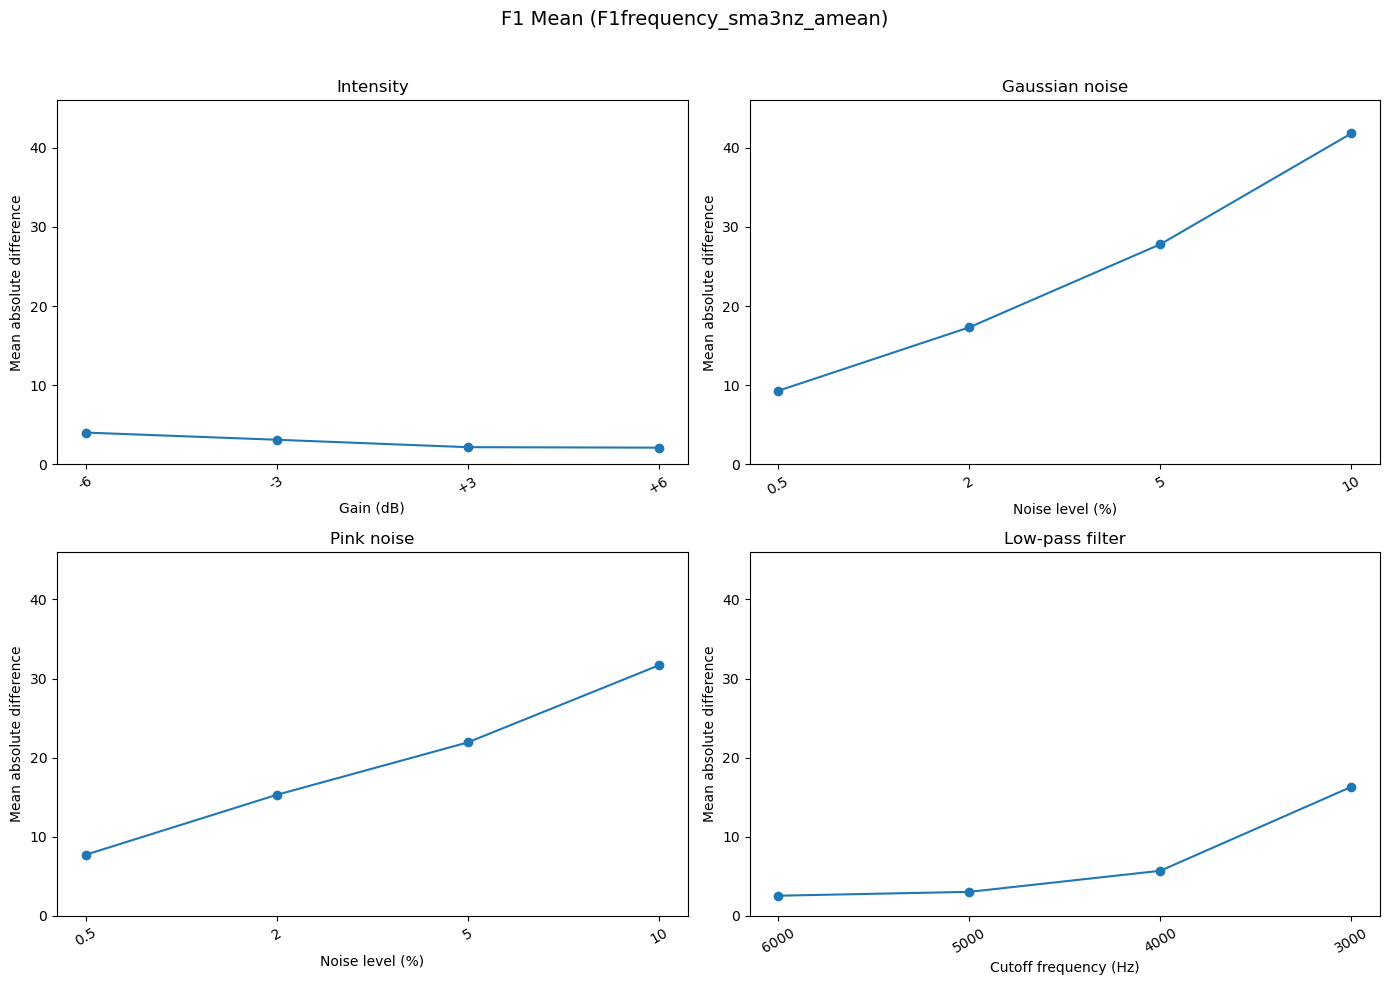

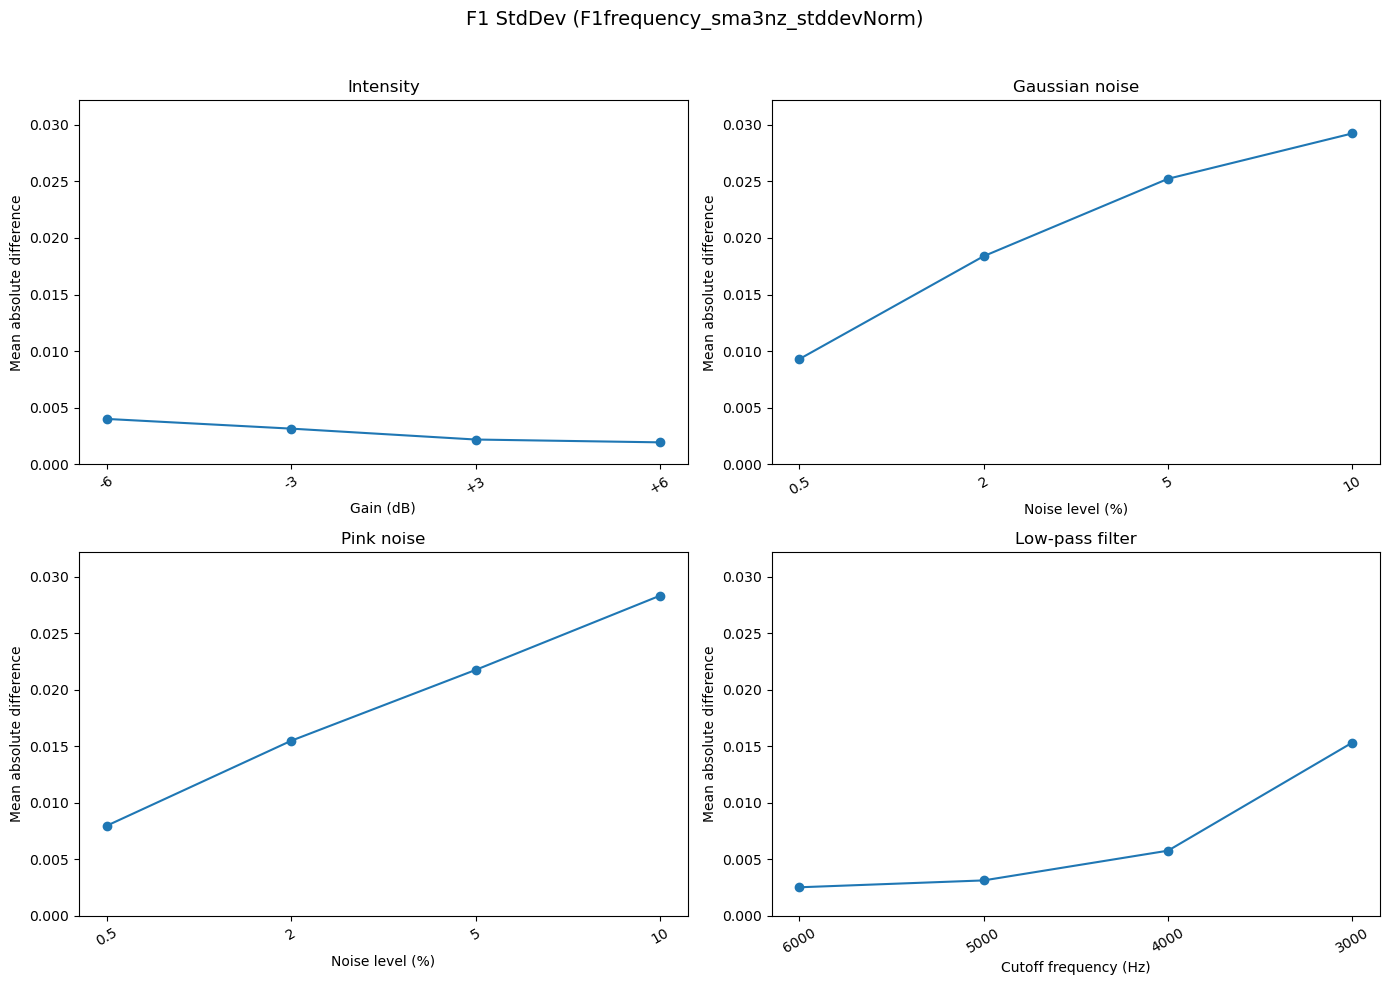

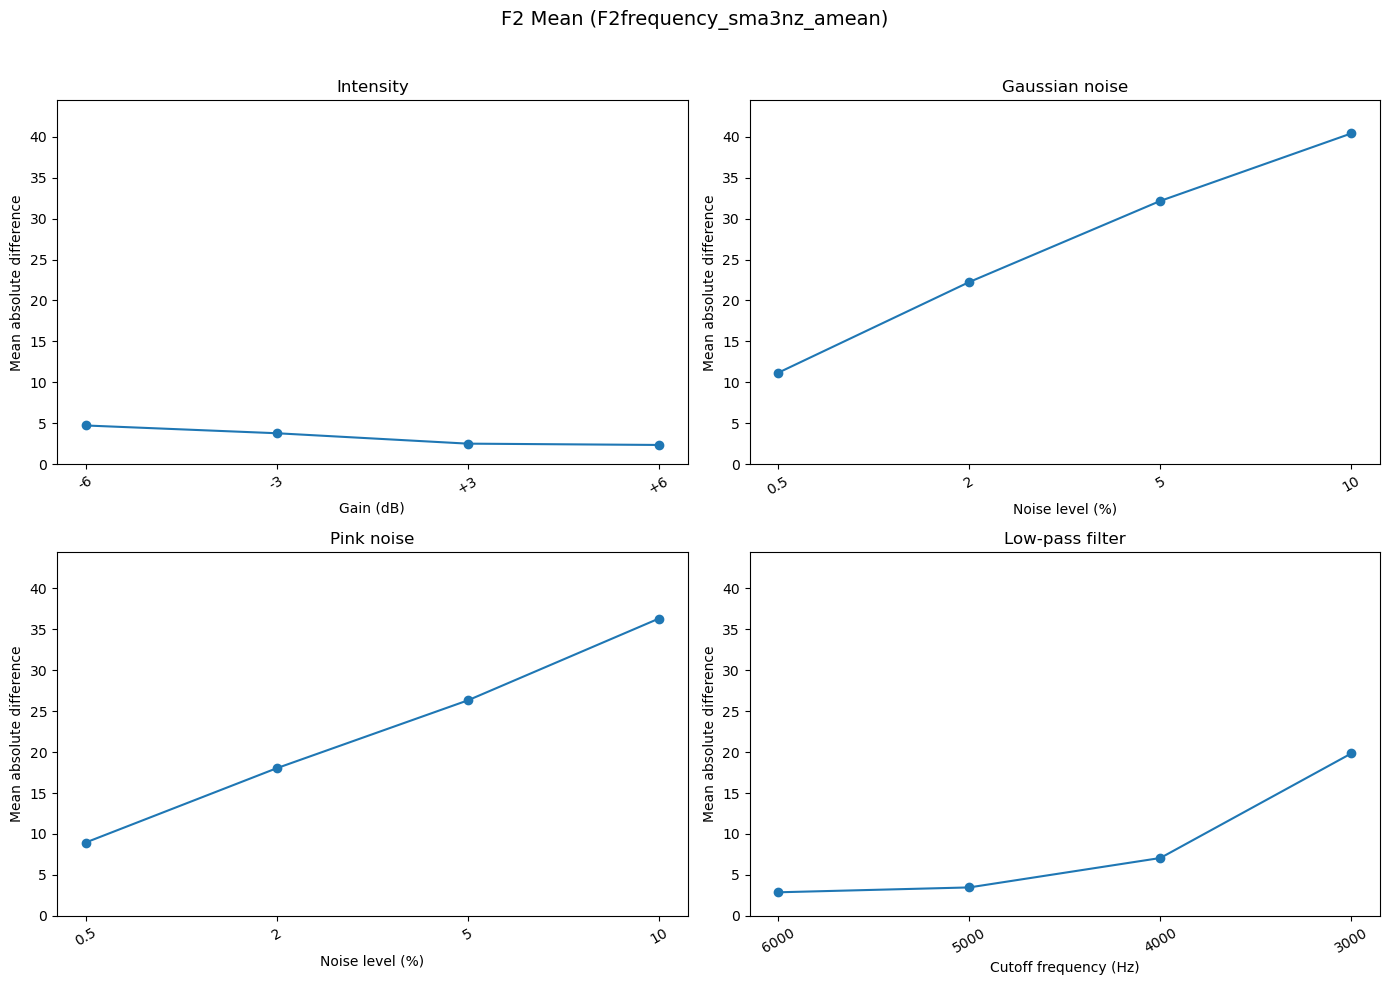

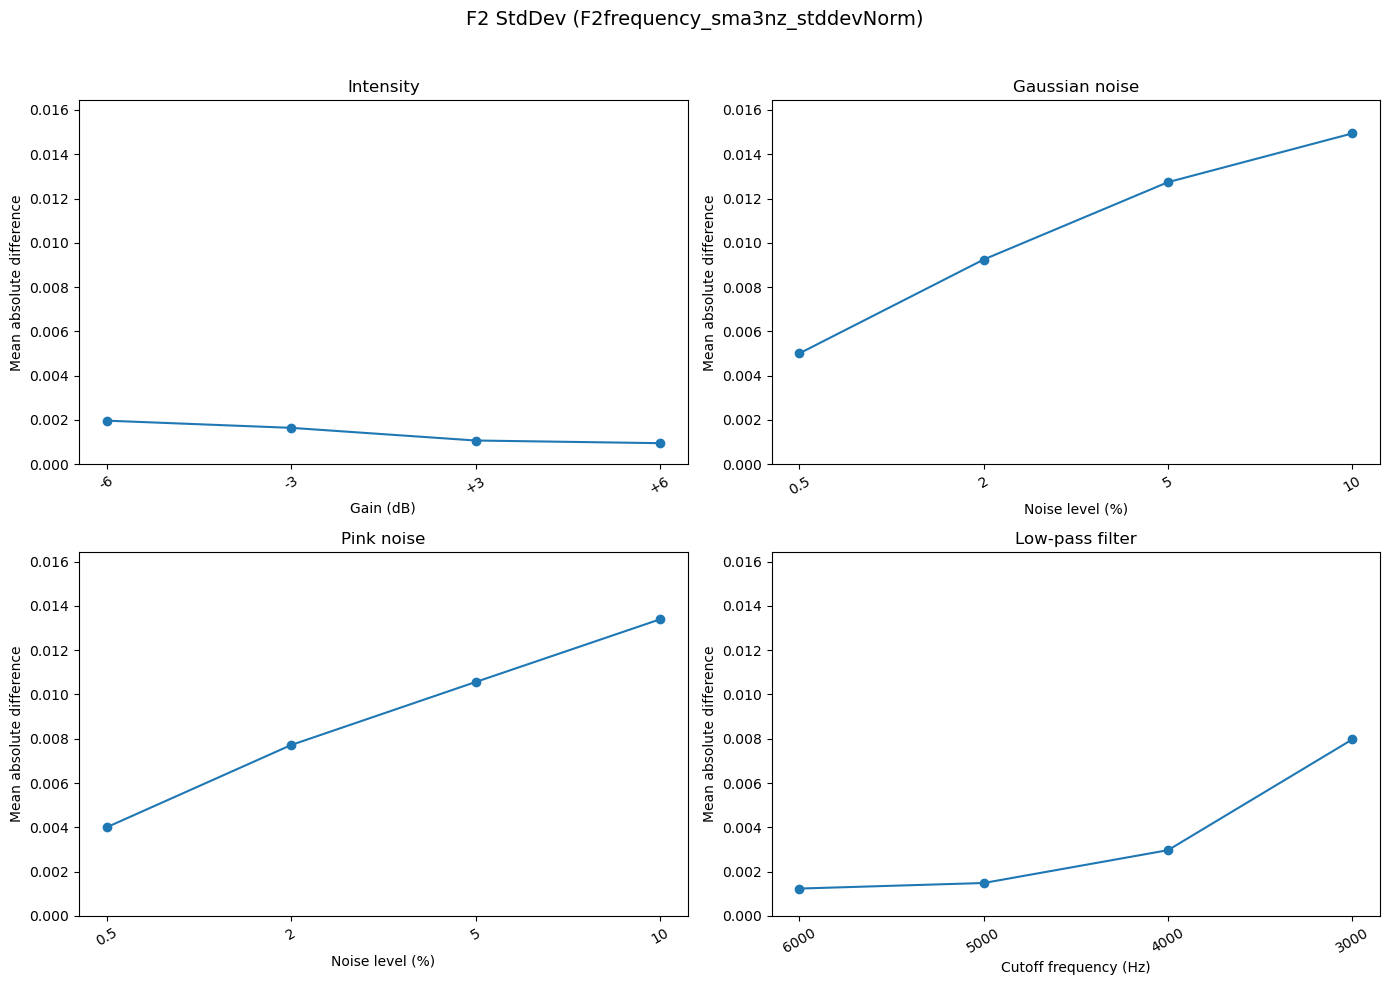

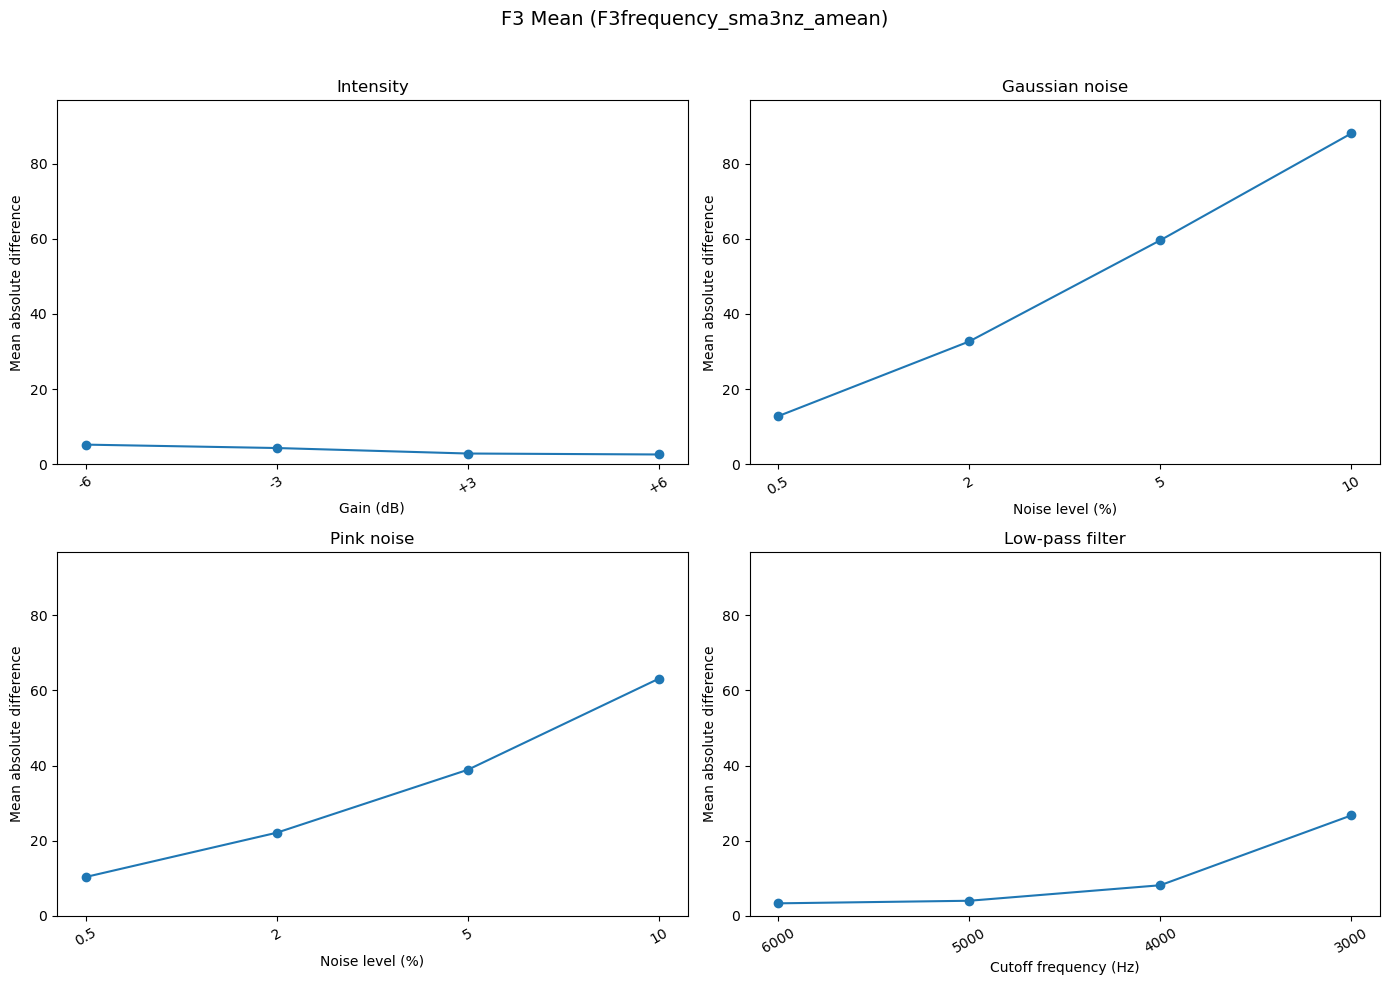

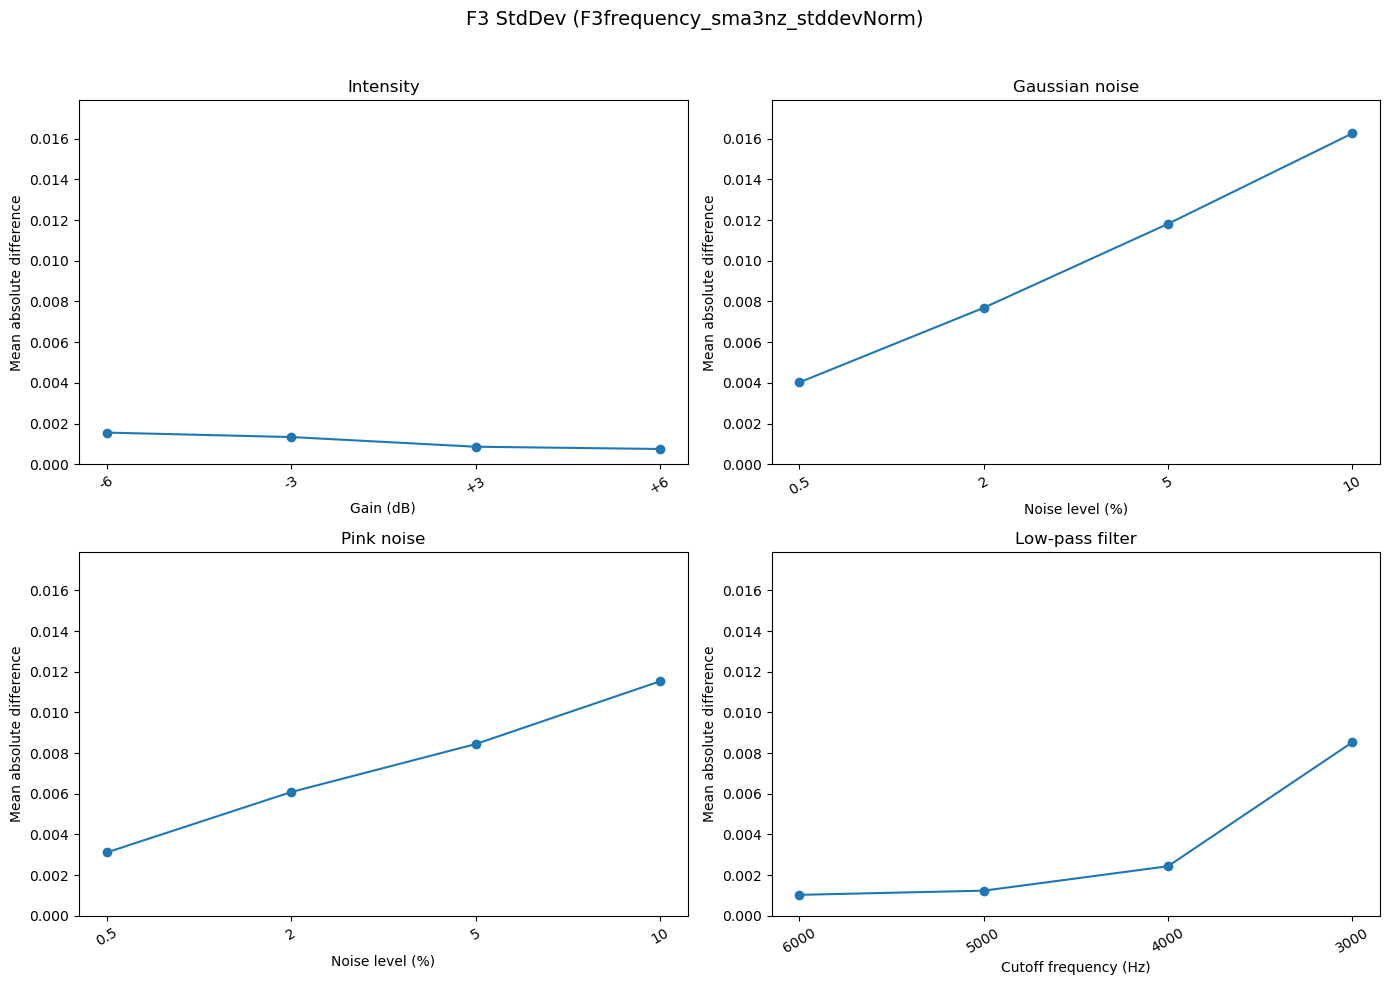

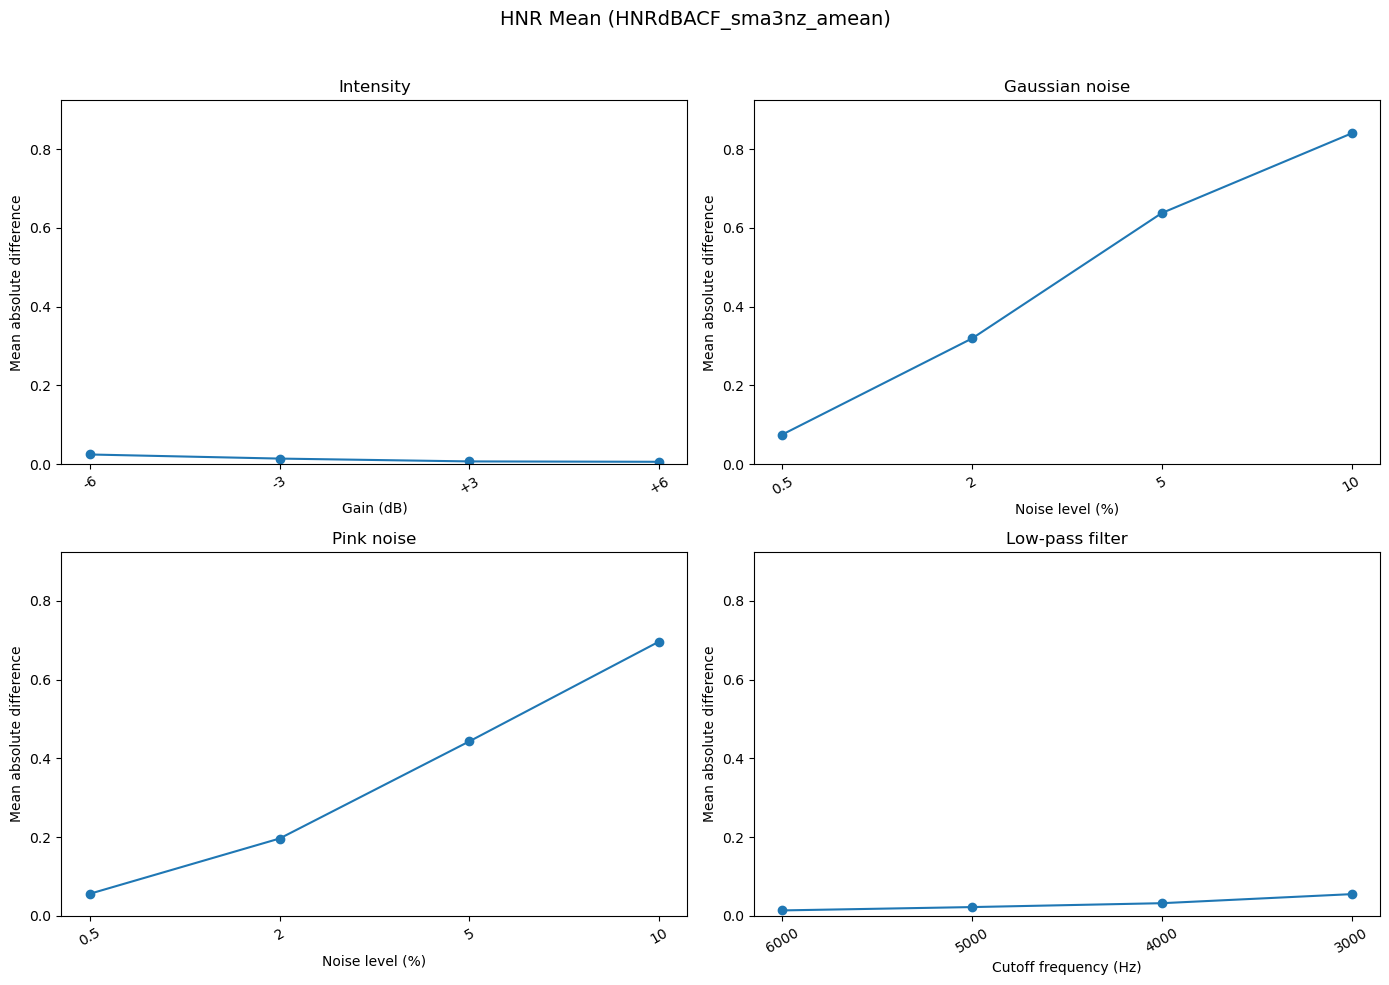

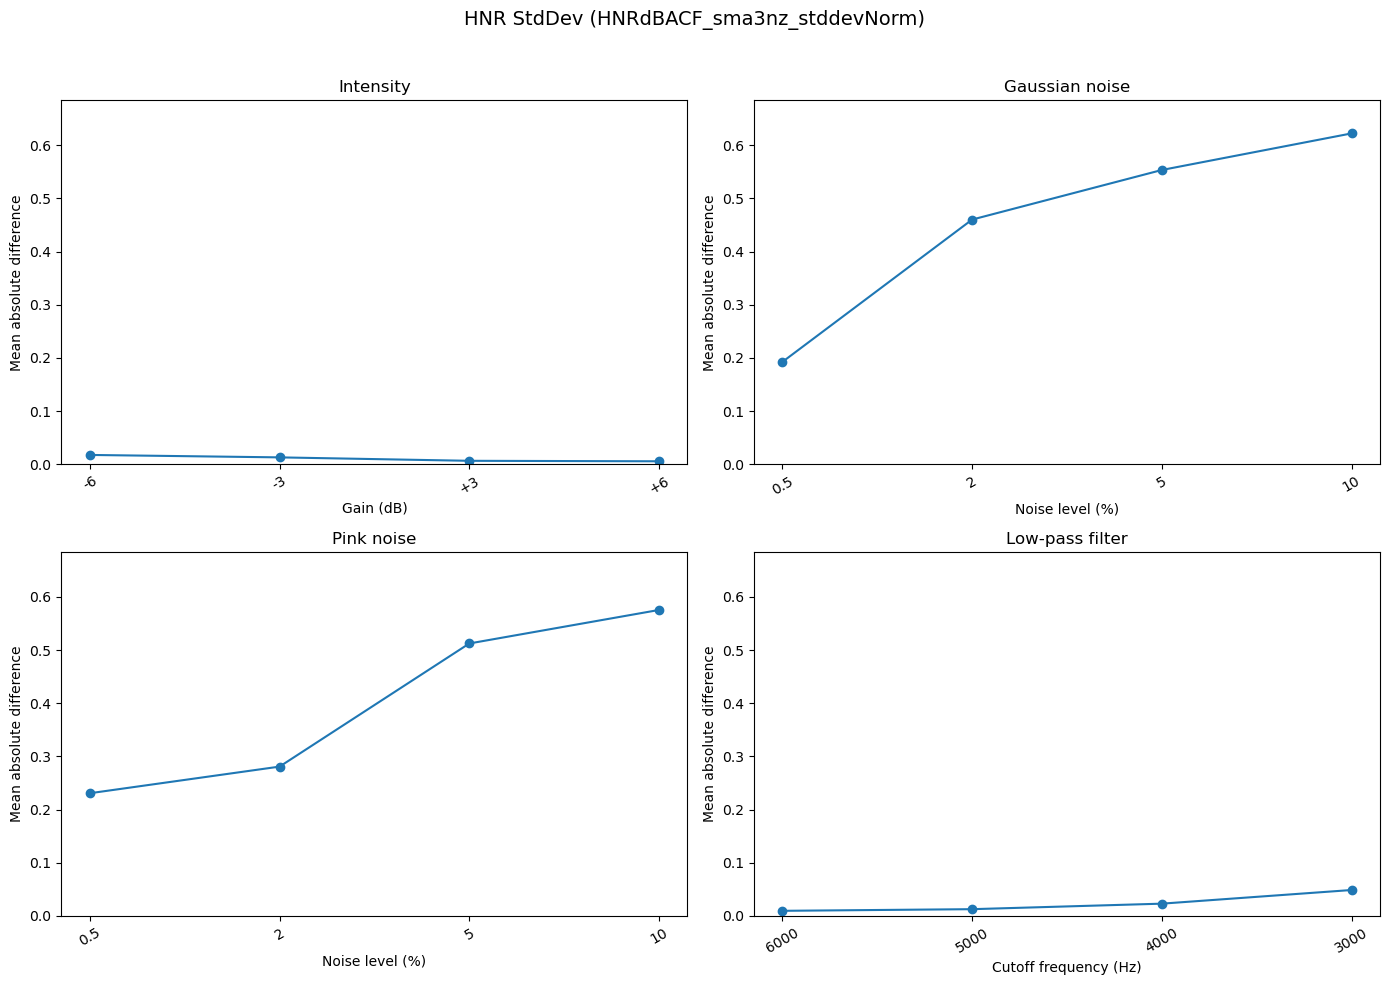

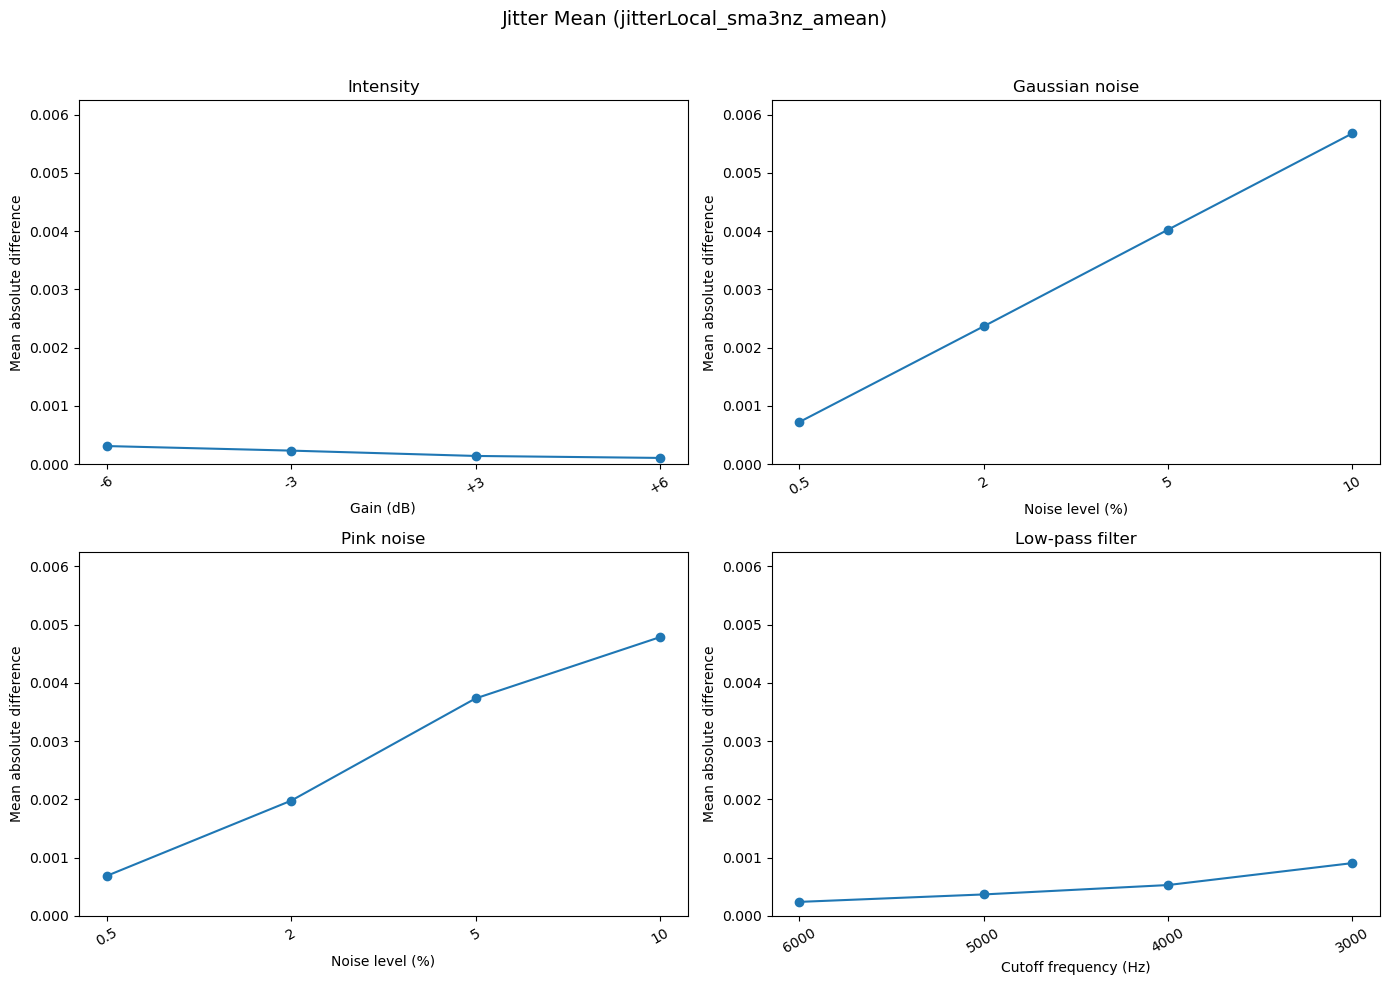

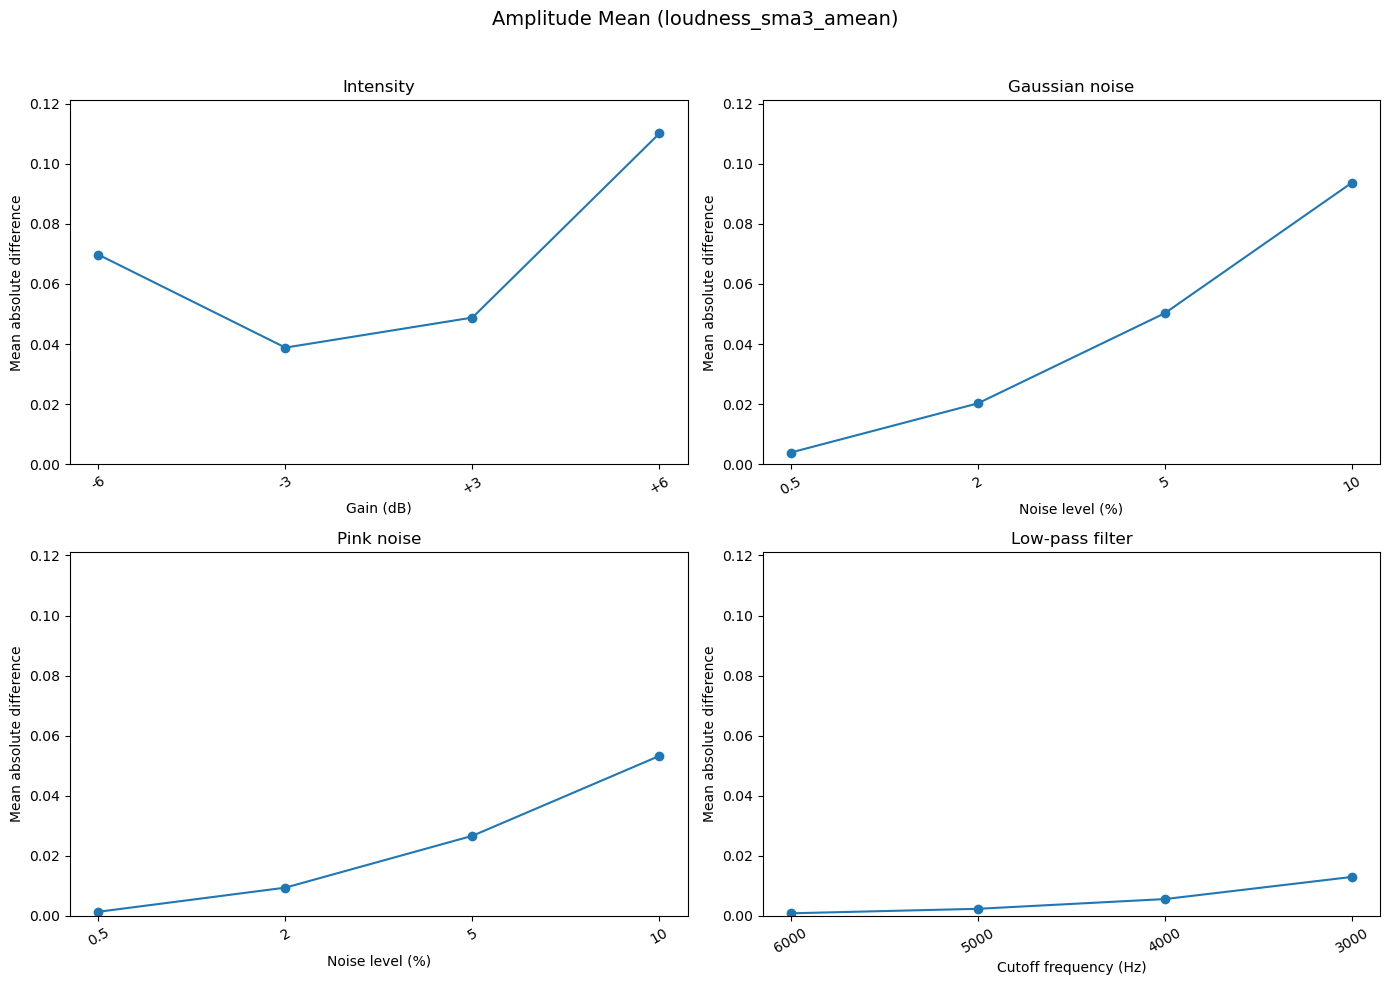

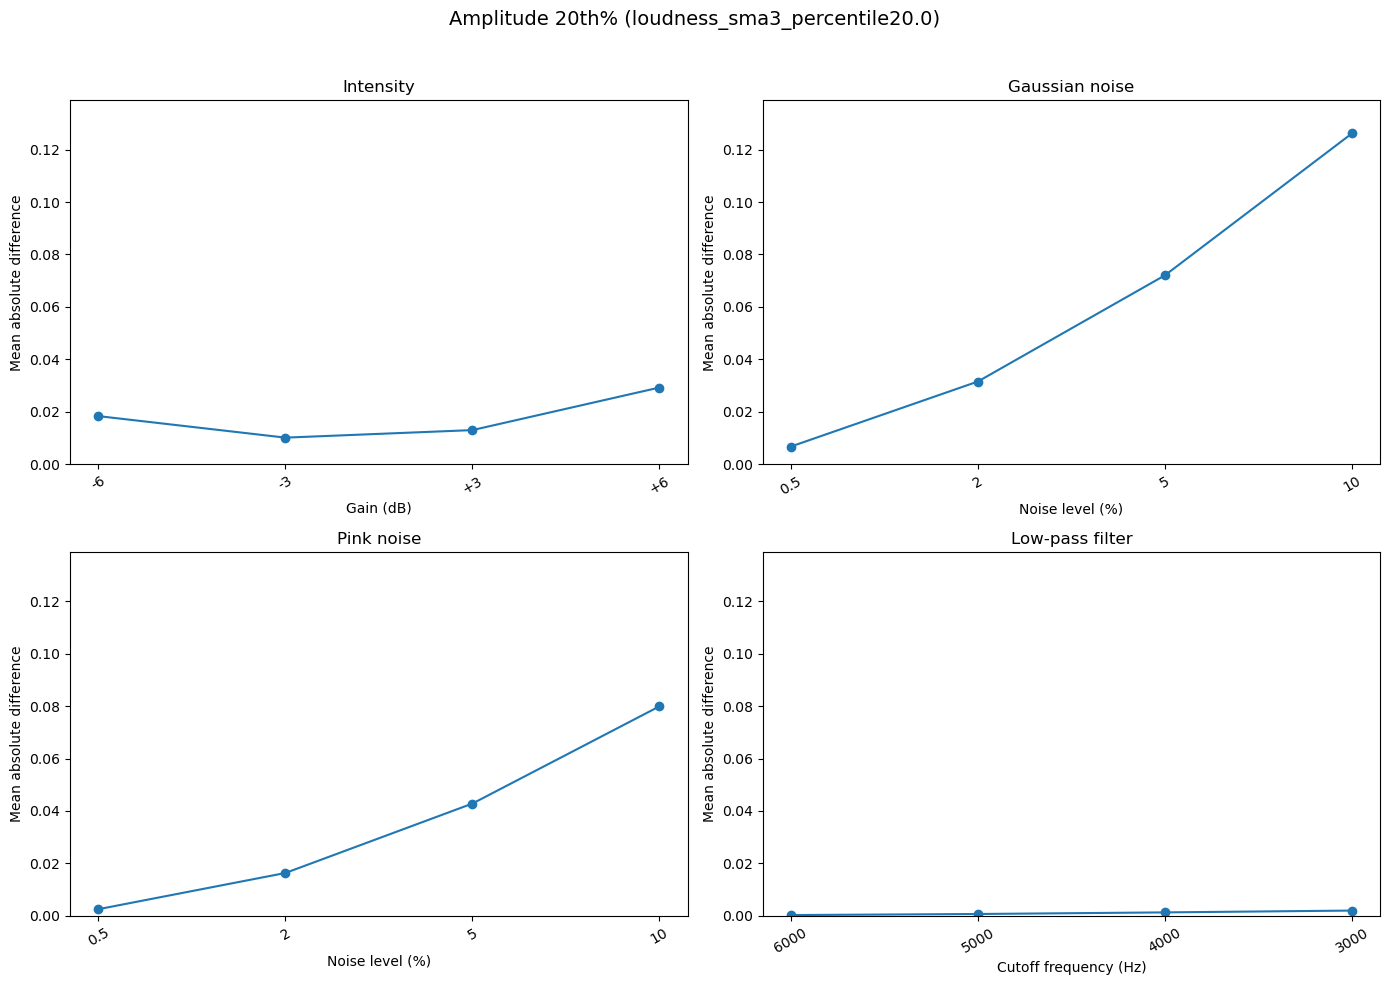

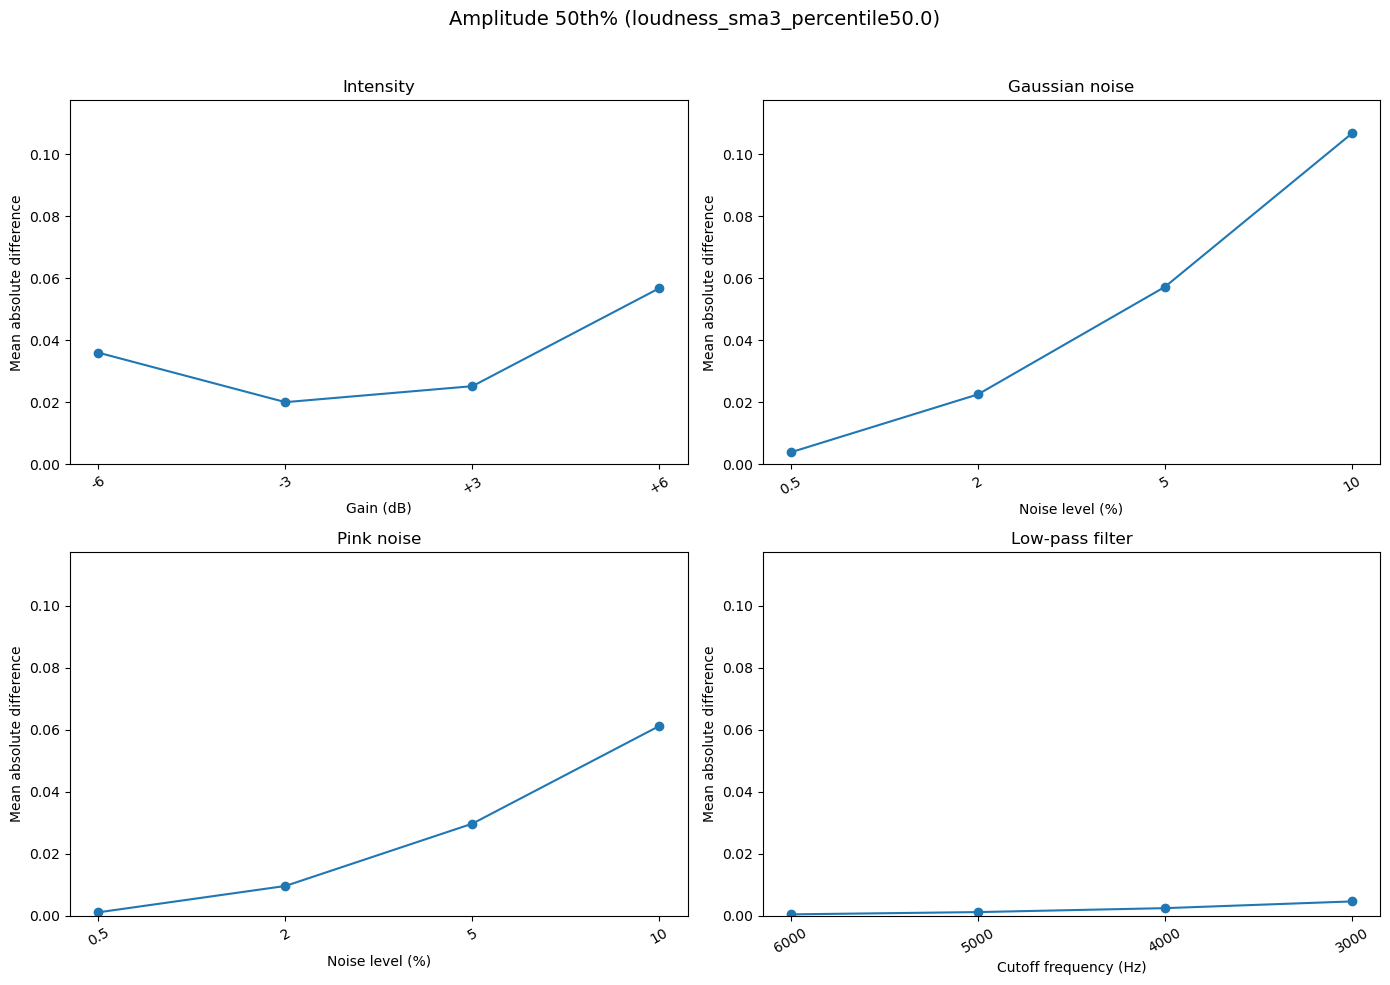

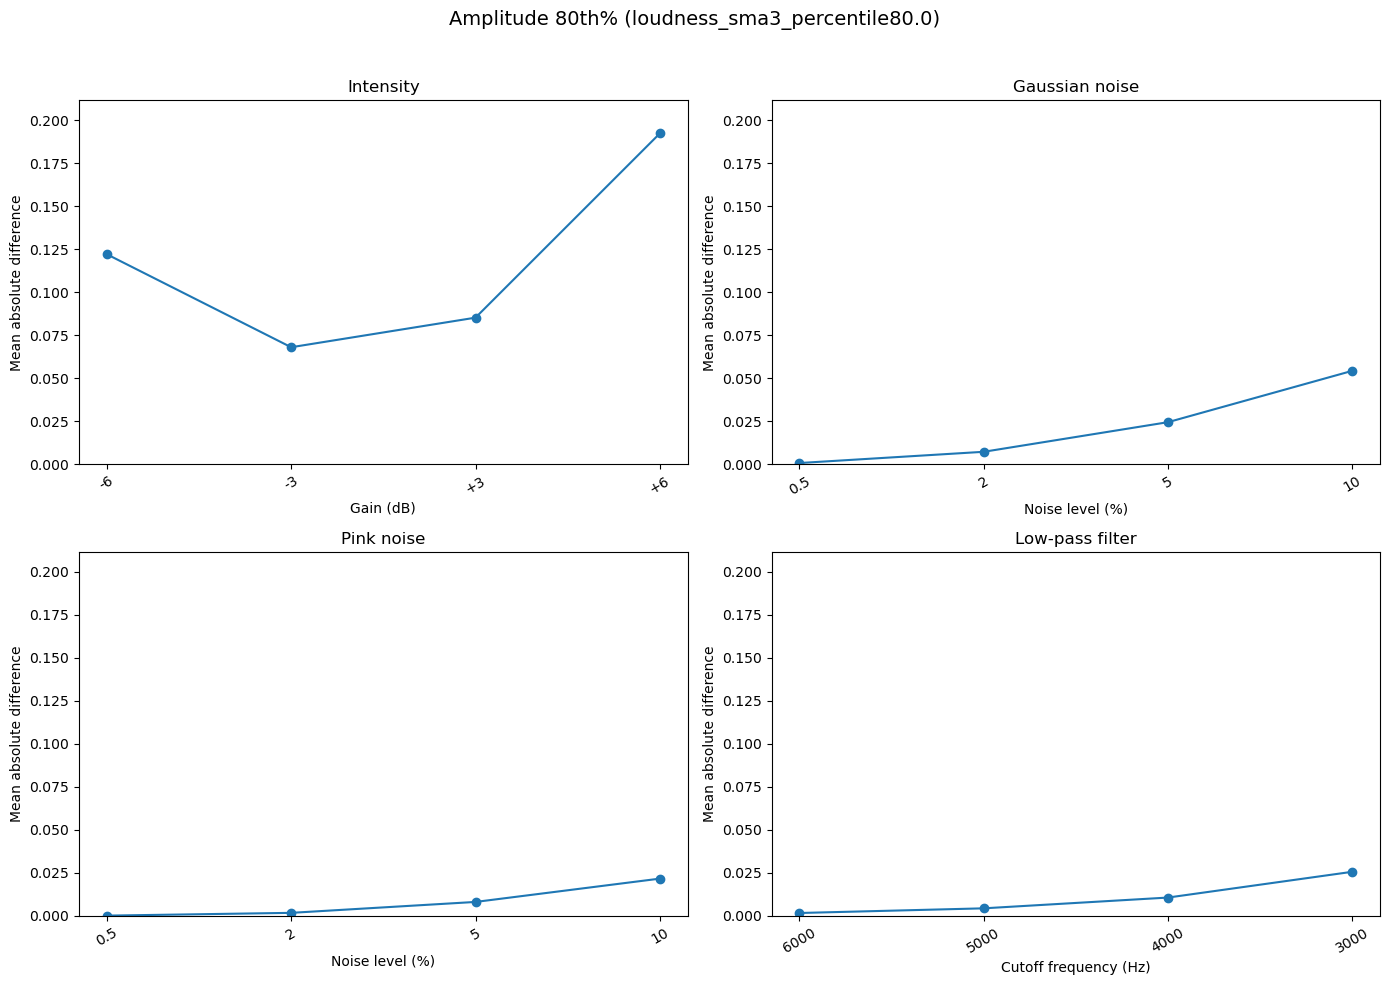

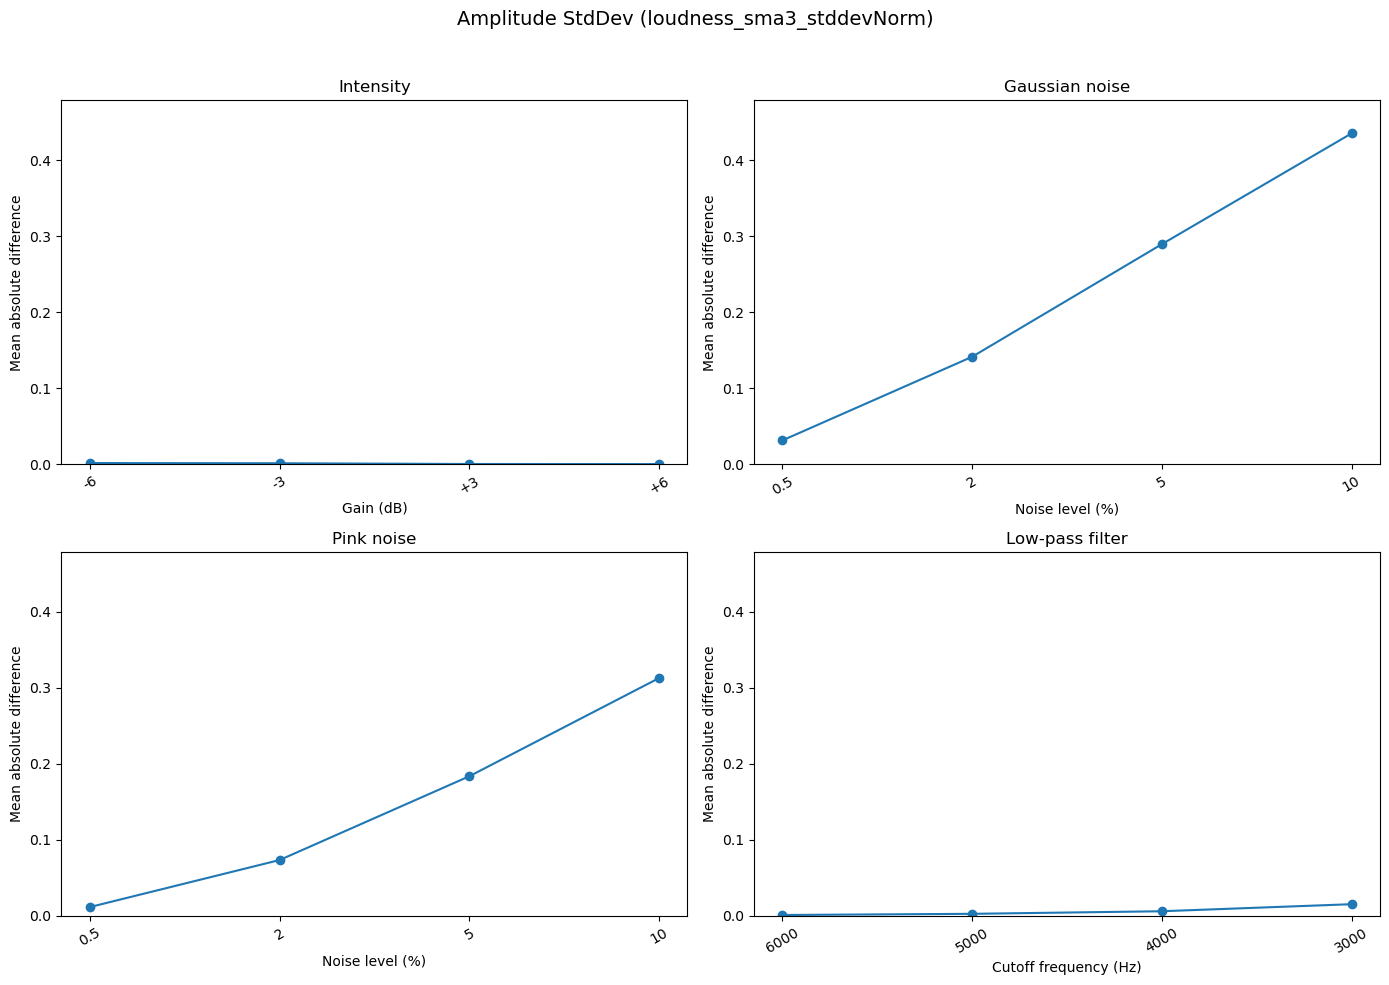

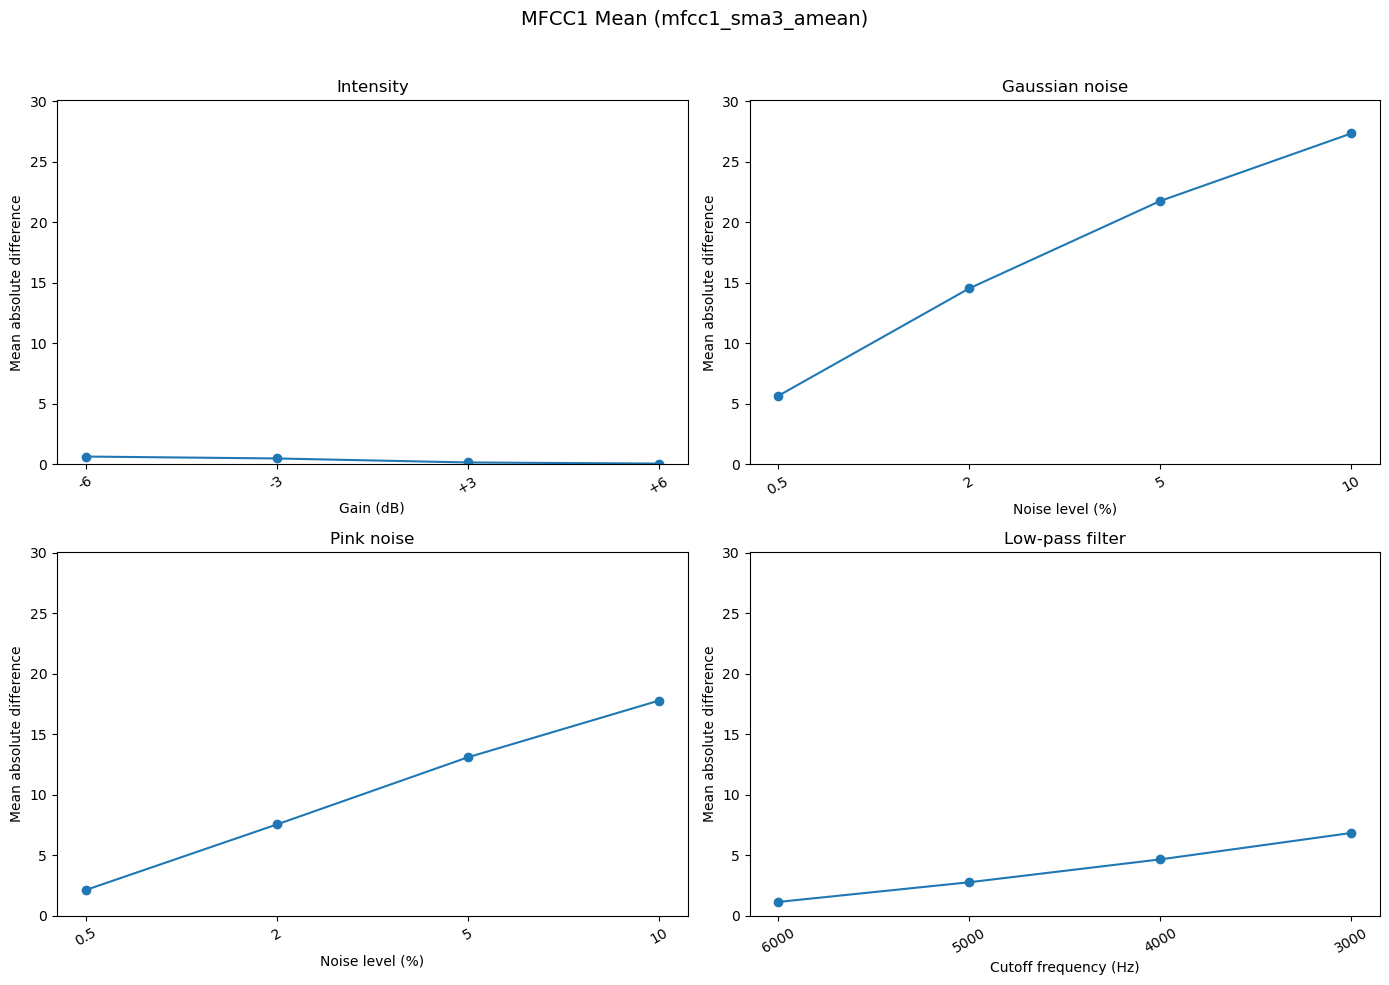

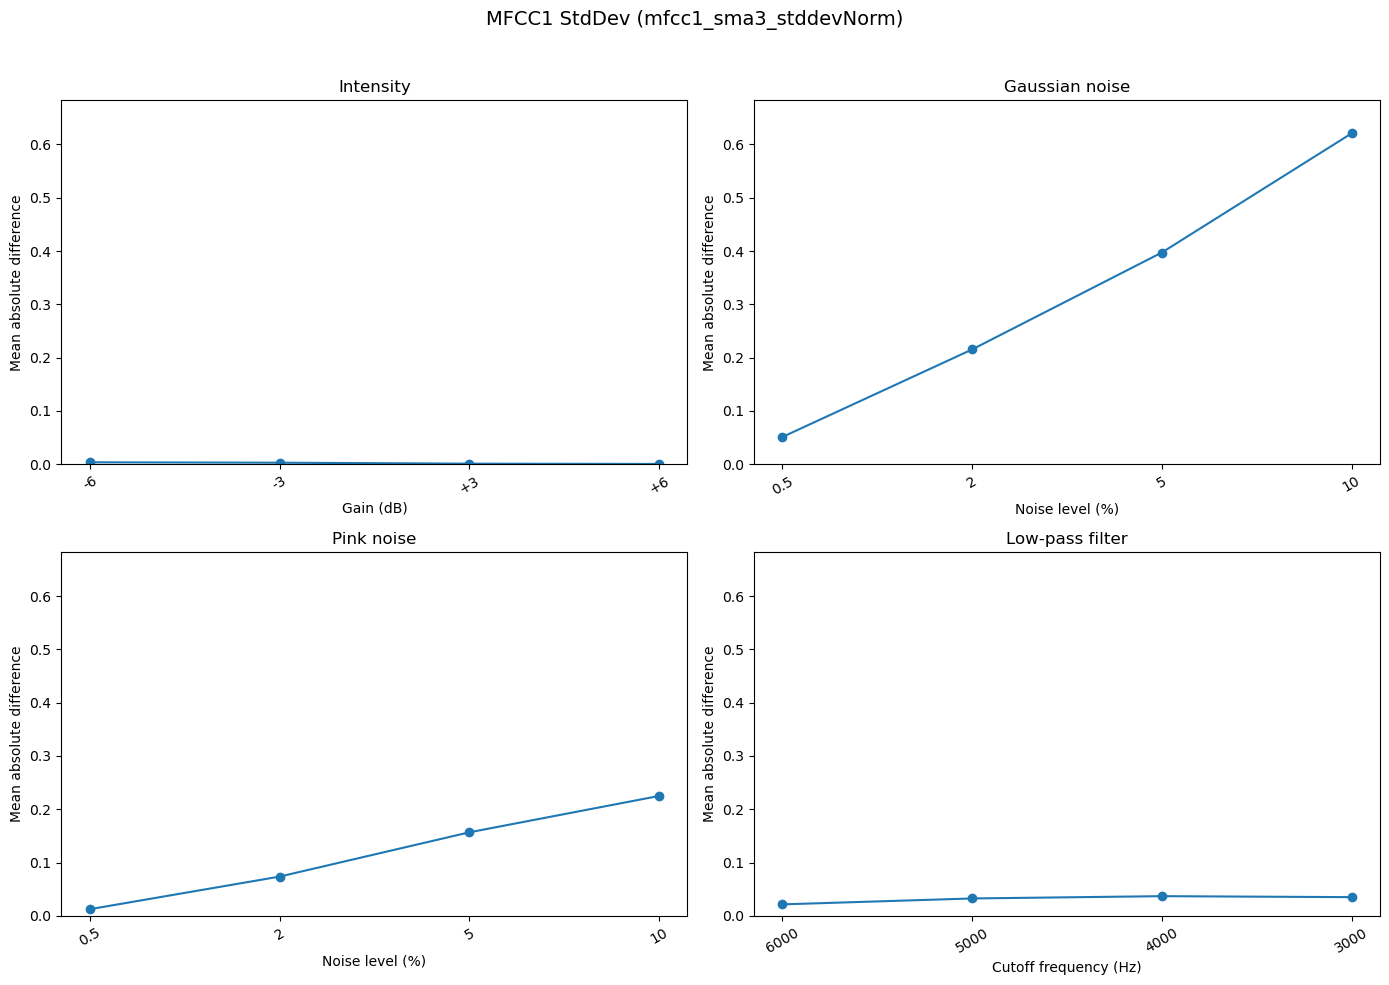

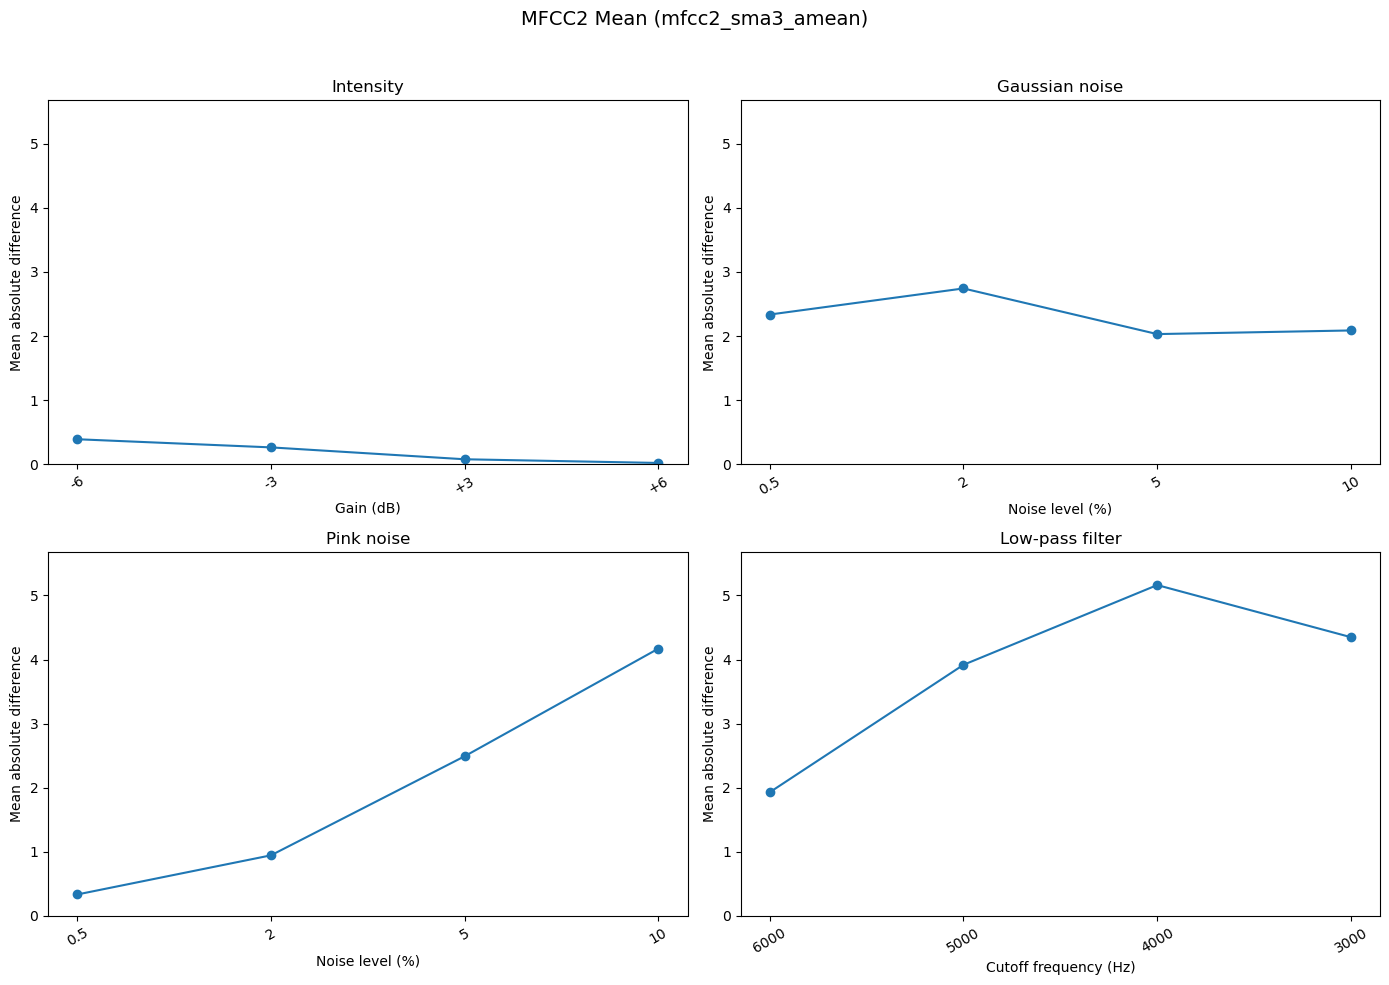

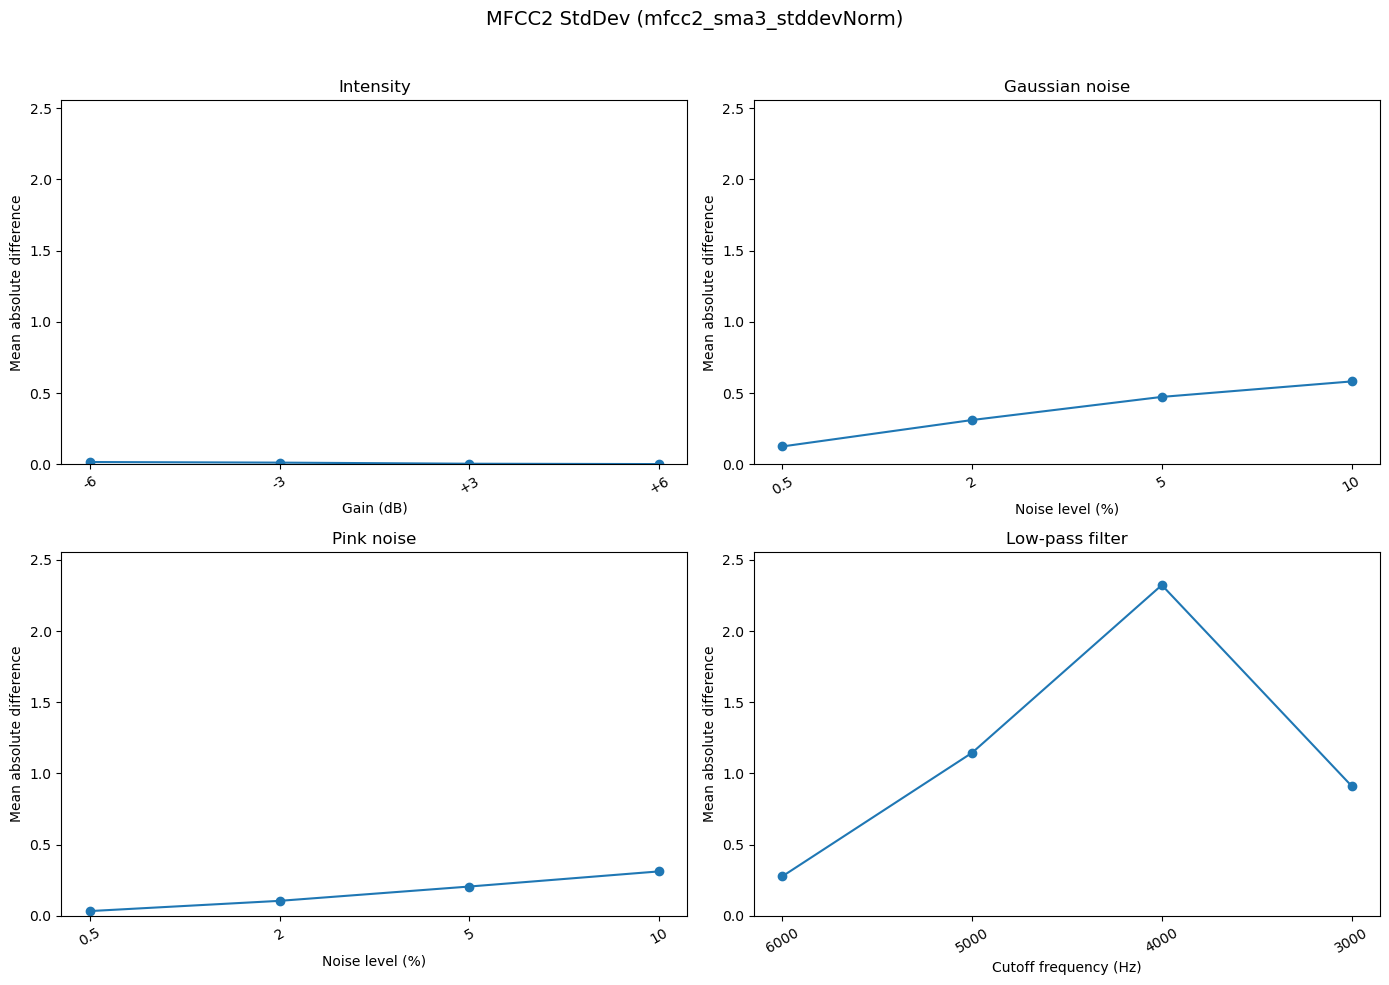

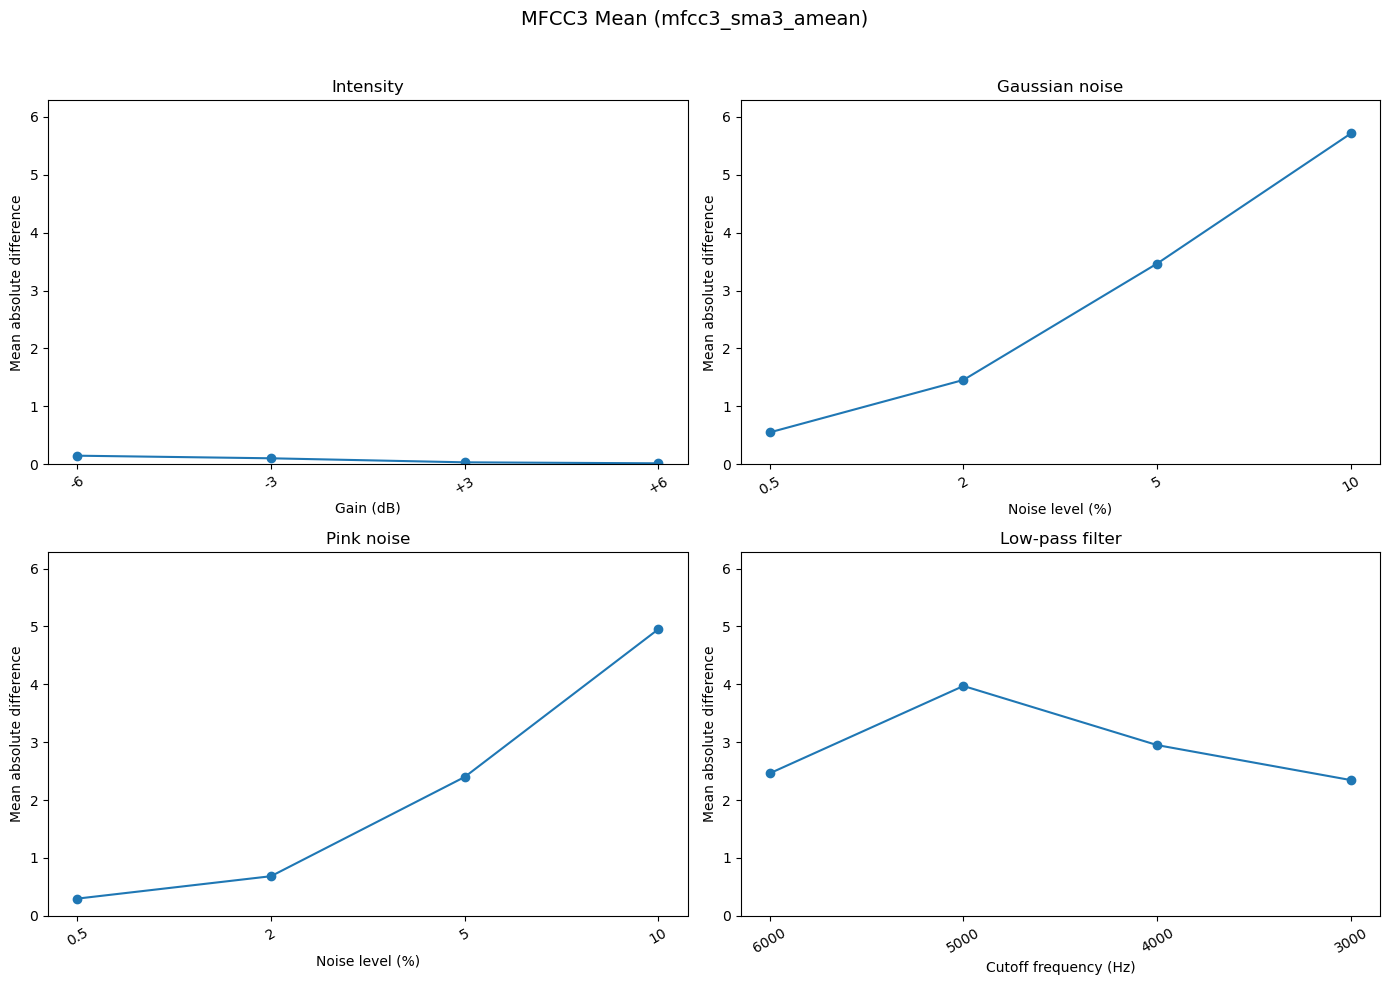

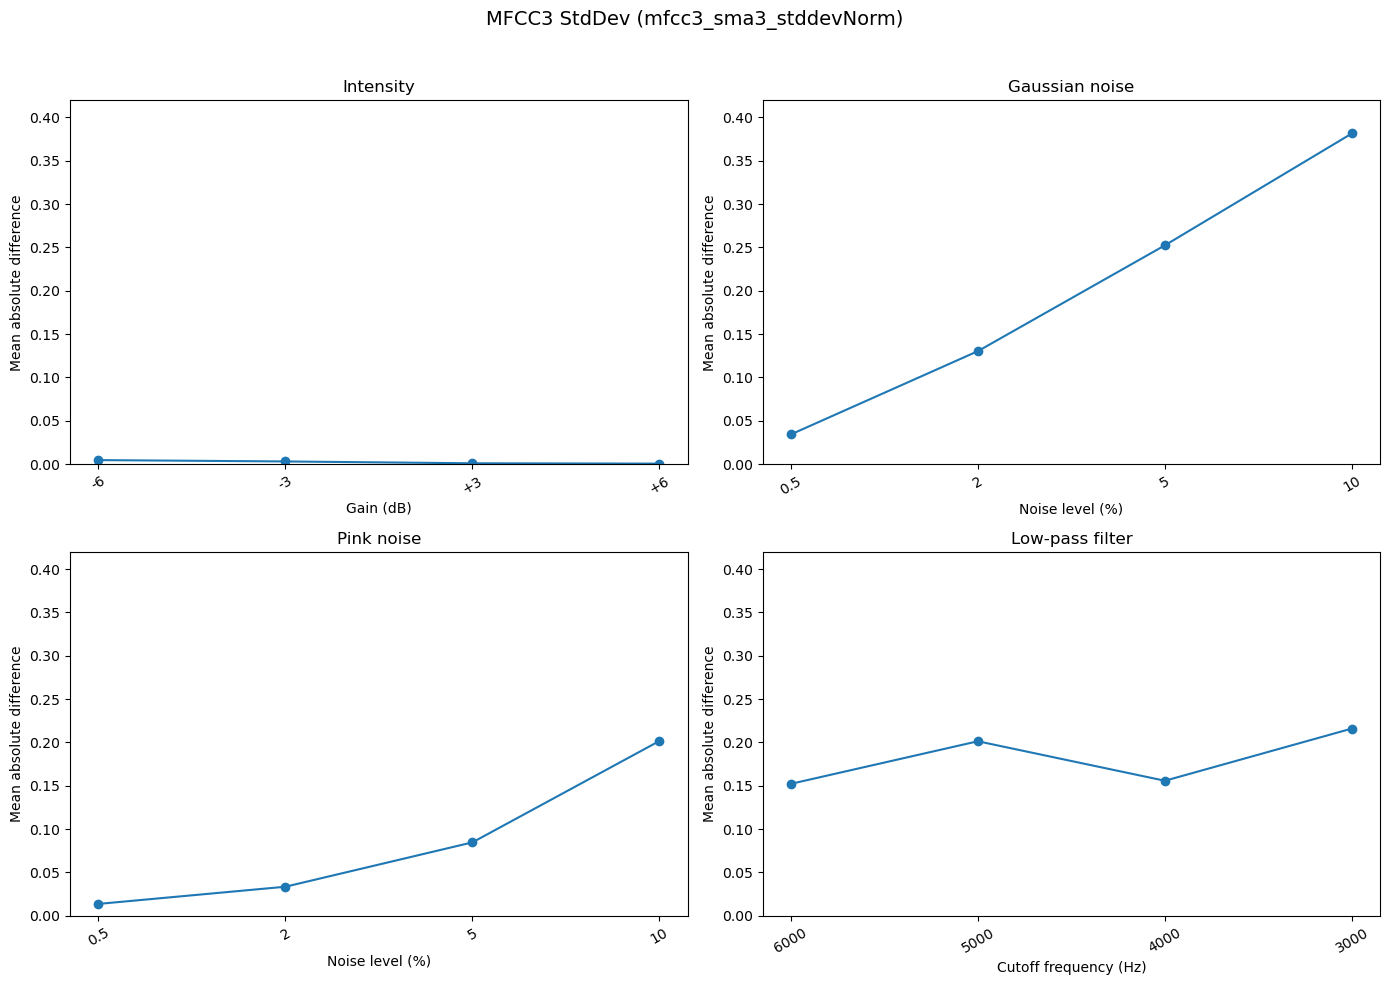

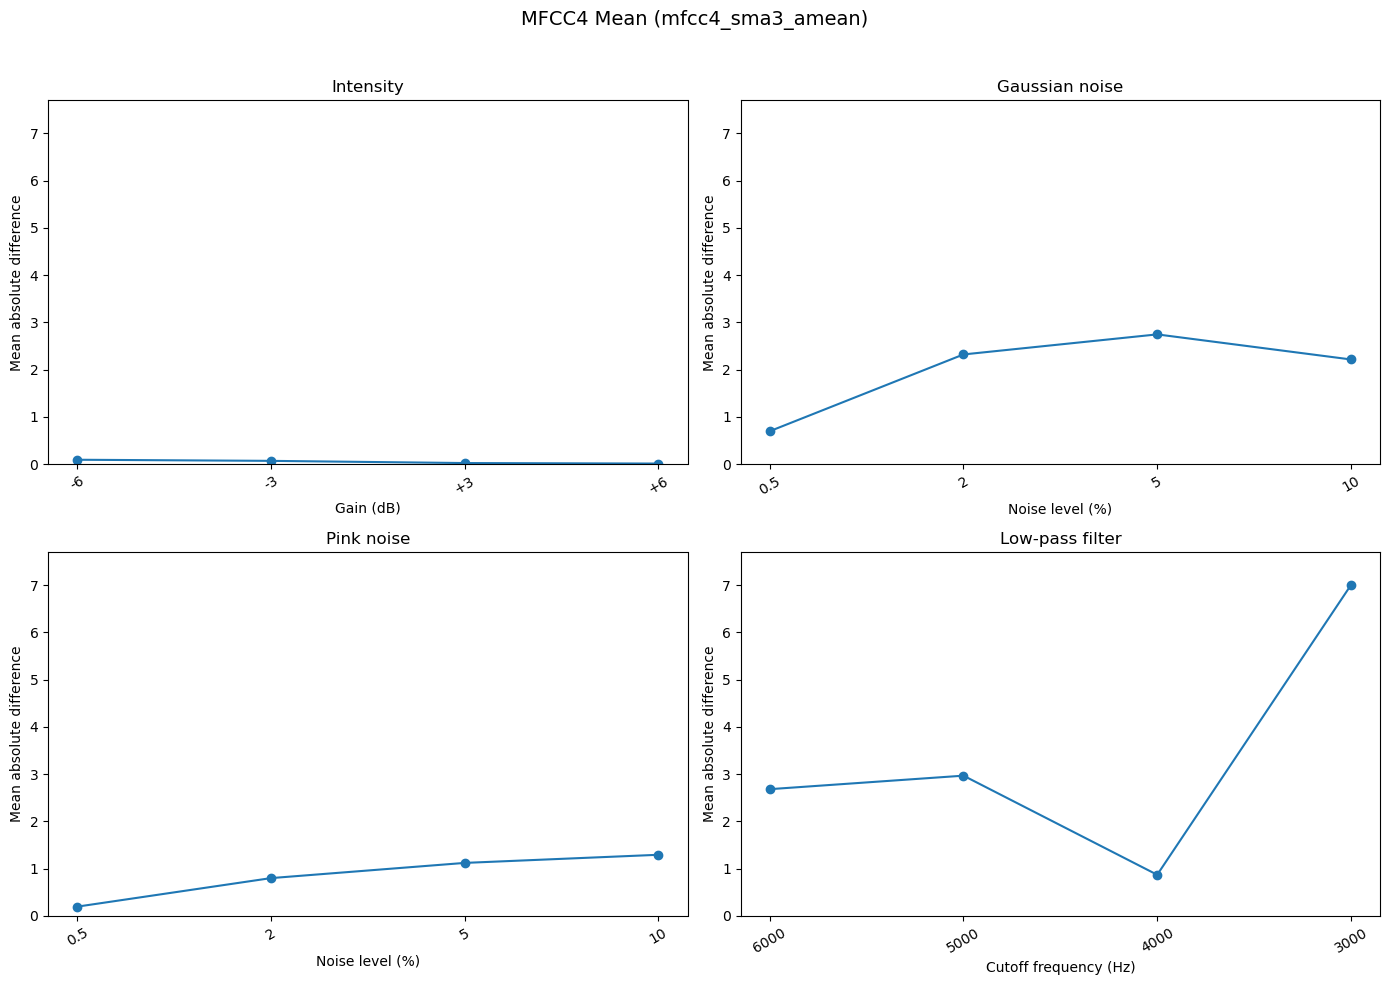

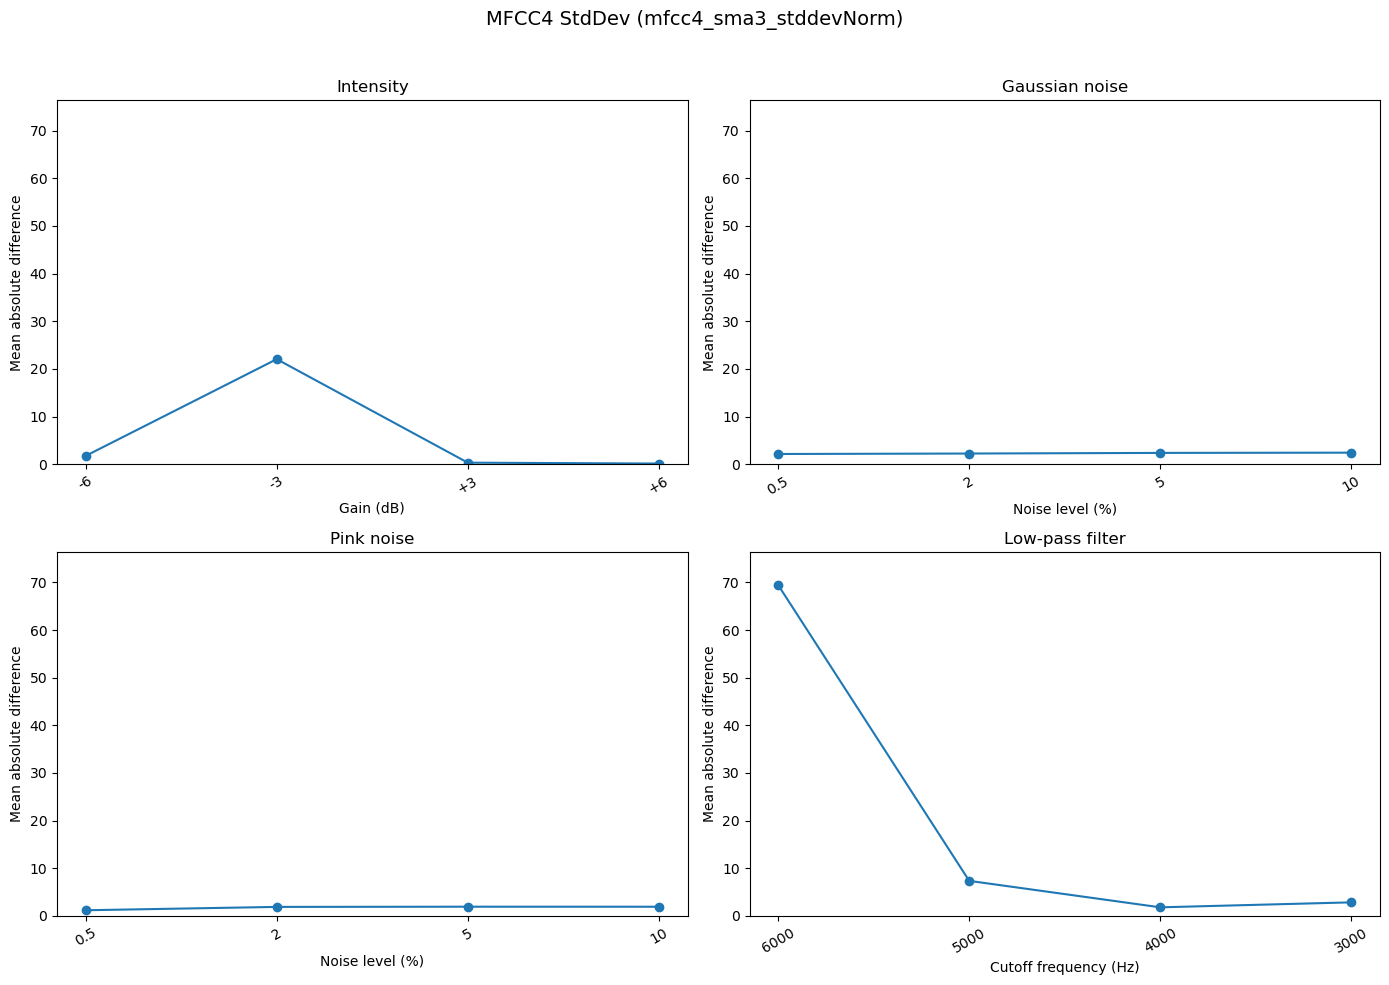

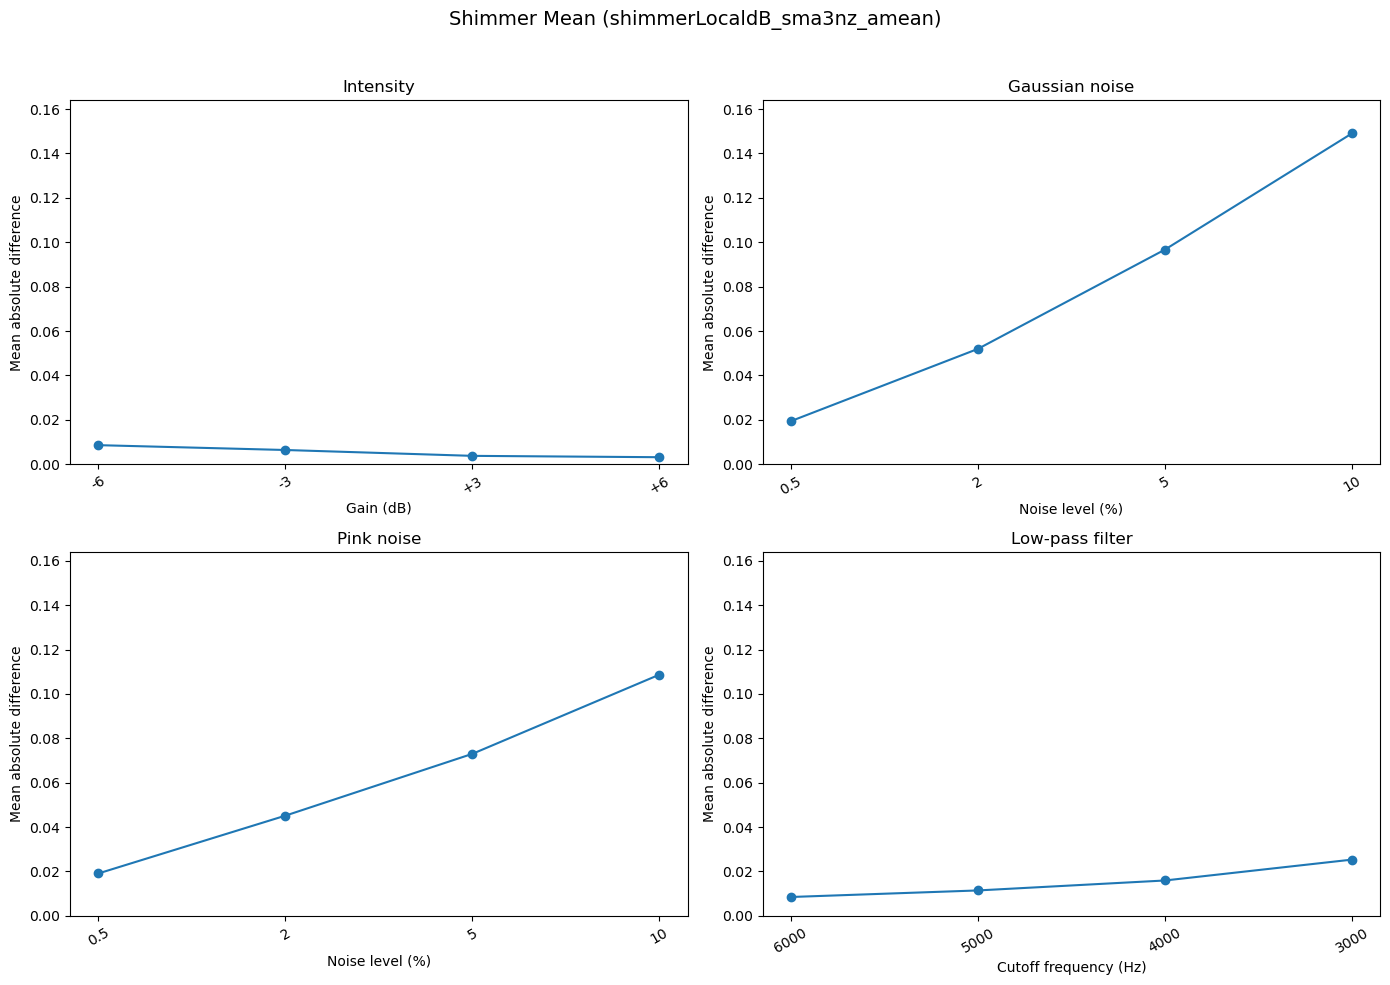

In [9]:
# subplots 
for feature_name, feature_col in selected_features.items():

    # Collect all mean absolute differences to determine y-axis limits
    all_values = []

    for group_name, dfs in all_data.items():
        original_df = dfs["original"]

        for label, df in dfs.items():
            if label == "original":
                continue

            abs_diff = np.abs(original_df[feature_col] - df[feature_col])
            mean_abs_diff = abs_diff.mean()

            all_values.append(mean_abs_diff)

    # Yaxis limits 
    y_min = 0  # logisch bij absolute differences
    y_max = max(all_values) * 1.1  # beetje ruimte bovenaan

    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, (group_name, dfs) in zip(axes, all_data.items()):
        original_df = dfs["original"]

        x_labels = []
        mean_abs_diffs = []

        for label, df in dfs.items():
            if label == "original":
                continue

            abs_diff = np.abs(original_df[feature_col] - df[feature_col])
            mean_abs_diff = abs_diff.mean()

            x_labels.append(label)
            mean_abs_diffs.append(mean_abs_diff)

        ax.plot(x_labels, mean_abs_diffs, marker="o")

        # y-axis
        ax.set_ylim(y_min, y_max)
        ax.set_title(group_name)
        if group_name == "Intensity":
            ax.set_xlabel("Gain (dB)")
        elif group_name == "Gaussian noise":
            ax.set_xlabel("Noise level (%)")
        elif group_name == "Pink noise":
            ax.set_xlabel("Noise level (%)")
        elif group_name == "Low-pass filter":
            ax.set_xlabel("Cutoff frequency (Hz)")
        ax.set_ylabel("Mean absolute difference")
        ax.tick_params(axis="x", rotation=30)

    fig.suptitle(f"{feature_name} ({feature_col})", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    file_name = safe_filename(feature_name) + ".png"
    plt.savefig(PLOTS_DIR / file_name, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()